In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader
import pmdarima as pm
import statsmodels.api as sm

import seaborn as sns
%config InlineBackend.figure_format='retina'
sns.set_style("darkgrid")

import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('../data')
sys.path.append('../src')

from plotly.offline import iplot
from plotly import graph_objs as go

from sklearn.metrics import mean_absolute_error

from scipy.optimize import minimize
from tqdm import tqdm

c:\Foranac\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Данные

In [ ]:
data = pd.read_csv('../data/dataset_exp.csv')
data = data.rename(columns={'Unnamed: 0':'Date'})
data['Date'] = pd.to_datetime(data['Date'])
data = data.set_index('Date')
data = data.asfreq('D').bfill()


Добавляем к нашим данные статистики из таблицы с данными по разладкам.

In [136]:
stats = pd.read_csv('../data/chang_point.csv')
stats['index'] = pd.to_datetime(stats['index'])
stats = stats.set_index('index')
stats['rolling_mean_shift']  = stats['rolling_mean'].shift(1)
stats['rolling_std_shift']  = stats['rolling_std'].shift(1)
stats = stats.asfreq('D').bfill()

In [137]:
data  = pd.merge(data, stats, right_index=True, left_index=True, how='left')
data

,Income,Outcome,Balance,is_holiday,is_workday,first_workday,last_workday,usd,eur,ruonia,...,week_day_5,week_day_6,is_holiday_balance,weekends,value,rolling_mean,rolling_std,segment_id,rolling_mean_shift,rolling_std_shift
Date,,,,,,,,,,,,,,,,,,,,,
2017-01-23,1.110718,1.220064,-0.109346,False,True,False,False,59.6697,63.7272,9.82,...,0,0,-0.000000,-0.000000,-0.109346,-0.181094,0.212895,0.0,-0.147625,0.238596
2017-01-24,1.040476,0.967100,0.073376,False,True,False,False,59.5034,63.9424,9.82,...,0,0,0.000000,0.000000,0.073376,-0.056012,0.086936,0.0,-0.181094,0.212895
2017-01-25,1.079964,1.193727,-0.113763,False,True,False,False,59.2168,63.6225,10.23,...,0,0,-0.000000,-0.000000,-0.113763,-0.053805,0.084868,0.0,-0.056012,0.086936
2017-01-26,0.978296,1.112359,-0.134064,False,True,False,False,59.1489,63.4254,10.38,...,0,0,-0.000000,-0.000000,-0.134064,-0.079539,0.086018,0.0,-0.053805,0.084868
2017-01-27,1.196396,1.395696,-0.198483,False,True,False,False,59.6356,64.0248,10.33,...,0,0,-0.000000,-0.000000,-0.199300,-0.096619,0.101612,0.0,-0.079539,0.086018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-03-27,2.172546,4.687433,-2.514887,False,False,False,False,75.7576,89.2576,4.31,...,1,0,-2.514887,-2.514887,-1.013855,-0.979621,0.957736,3.0,-0.940120,0.960041
2021-03-28,2.172546,4.687433,-2.514887,False,False,False,False,75.7576,89.2576,4.31,...,0,1,-2.514887,-2.514887,-1.013855,-0.979621,0.957736,3.0,-0.940120,0.960041
2021-03-29,2.356883,3.370738,-1.017679,False,True,False,False,75.7576,89.2576,4.45,...,0,0,-0.000000,-0.000000,-1.013855,-0.979621,0.957736,3.0,-0.940120,0.960041


In [174]:
exog_features = ['is_holiday',
        'first_workday', 'last_workday', 
        'usd', 'eur', 'ruonia','vol_ruonia', 
        'lag_1', 'lag_2', 'lag_3',  'lag_5', 
       'rolling_mean_7', 'rolling_std_7', 'rolling_min_7','rolling_max_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_min_14','rolling_max_14', 
       'day_of_month', 'is_month_start',
       'is_month_end', 'is_month_start_lag', 'is_month_end_lag',
       'rate_russ','real_inflation', 'target_inflation', 'real_target_diff', 'rate_usa',
       'tax_day', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8',
       'month_9', 'month_10', 'month_11', 'month_12', 
       'quarter_2', 'quarter_3', 'quarter_4', 
       'year_2018', 'year_2019', 'year_2020', 'year_2021',
       'week_day_1', 'week_day_2', 'week_day_3', 'week_day_4', 'week_day_5',
       'week_day_6','rolling_mean_shift','rolling_std_shift','segment_id']

Не прогнозируем 2021 год, так как алгоритм показал, что там разладка.

In [318]:
data = data[data.index.year < 2021]
features = data[exog_features]
target = data['Balance']

train = features[features.index.year < 2020]
test = target[target.index.year >= 2020]

# Linreg

In [320]:
from sklearn.linear_model import LinearRegression

len_train = len(train)

X_train = features.iloc[:len_train,:]
y_train = target.iloc[:len_train]

preds = []
for i in tqdm(range(7, len(test)+7, 7)):

    if i >= len(test):
        i = len(test)

    model = LinearRegression()
    model.fit(X_train, y_train)
    prediction = model.predict(X_train)

    X_train = features.iloc[:len_train+i,:]
    y_train = target.iloc[:len_train+i]
    
    prediction = model.predict(X_train)

    idx = 7 if i % 7 == 0 else i % 7
    preds.extend(prediction[-idx:])
lin_pred = preds

100%|██████████| 53/53 [00:00<00:00, 59.96it/s]


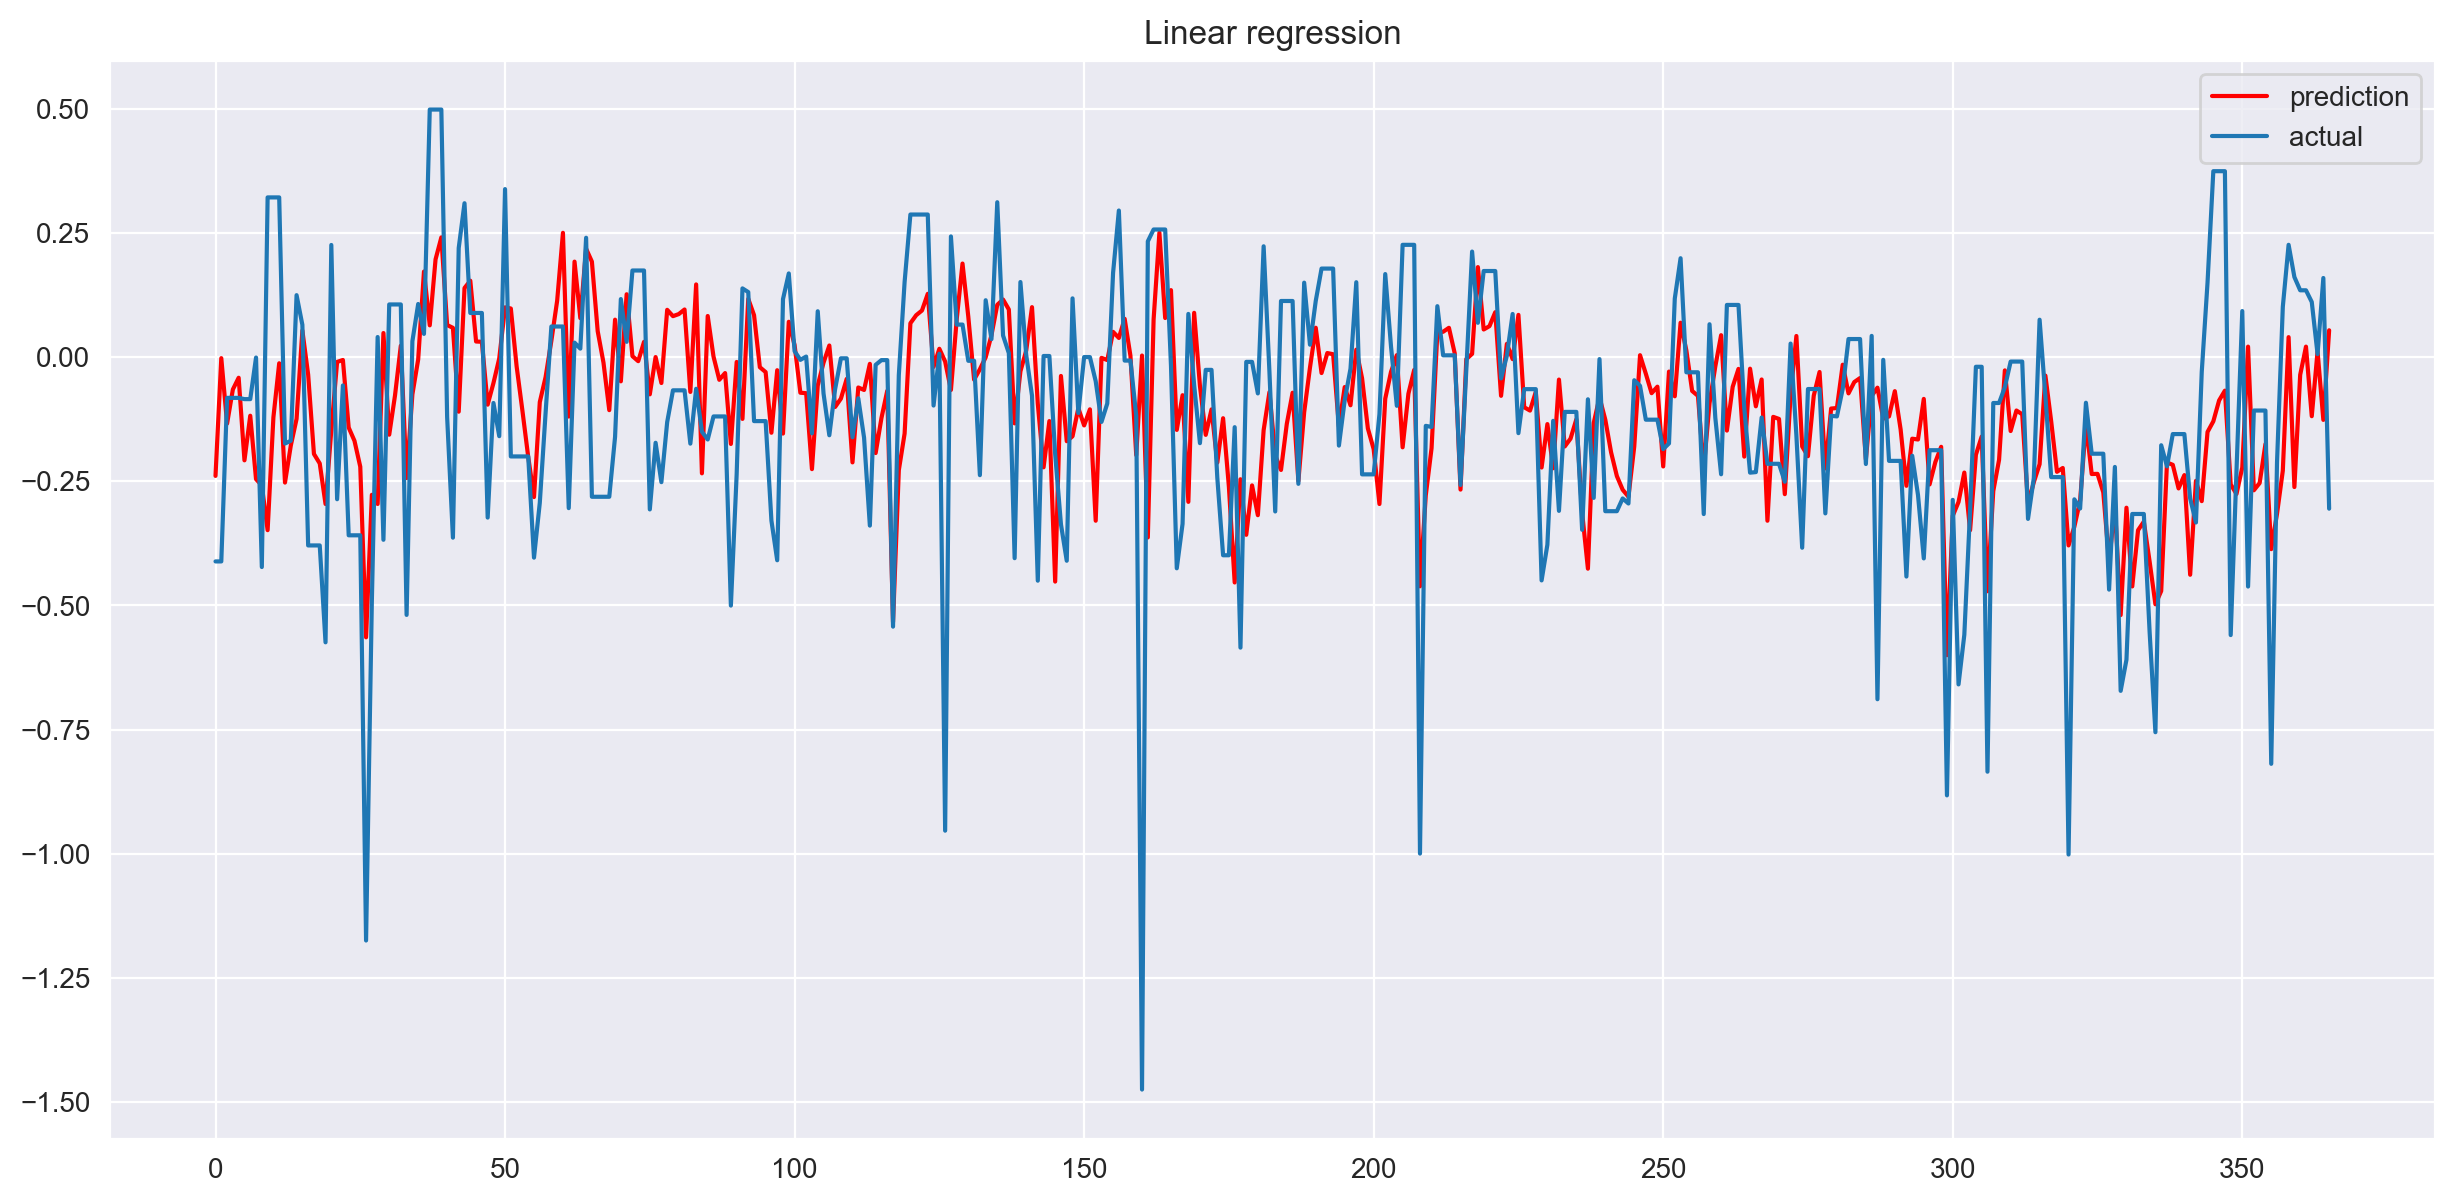

In [321]:
plt.figure(figsize=(15, 7))
plt.plot(lin_pred, "r", label="prediction")
plt.plot(test.values, label="actual")
plt.legend(loc="best")
plt.title("Linear regression")
plt.grid(True)

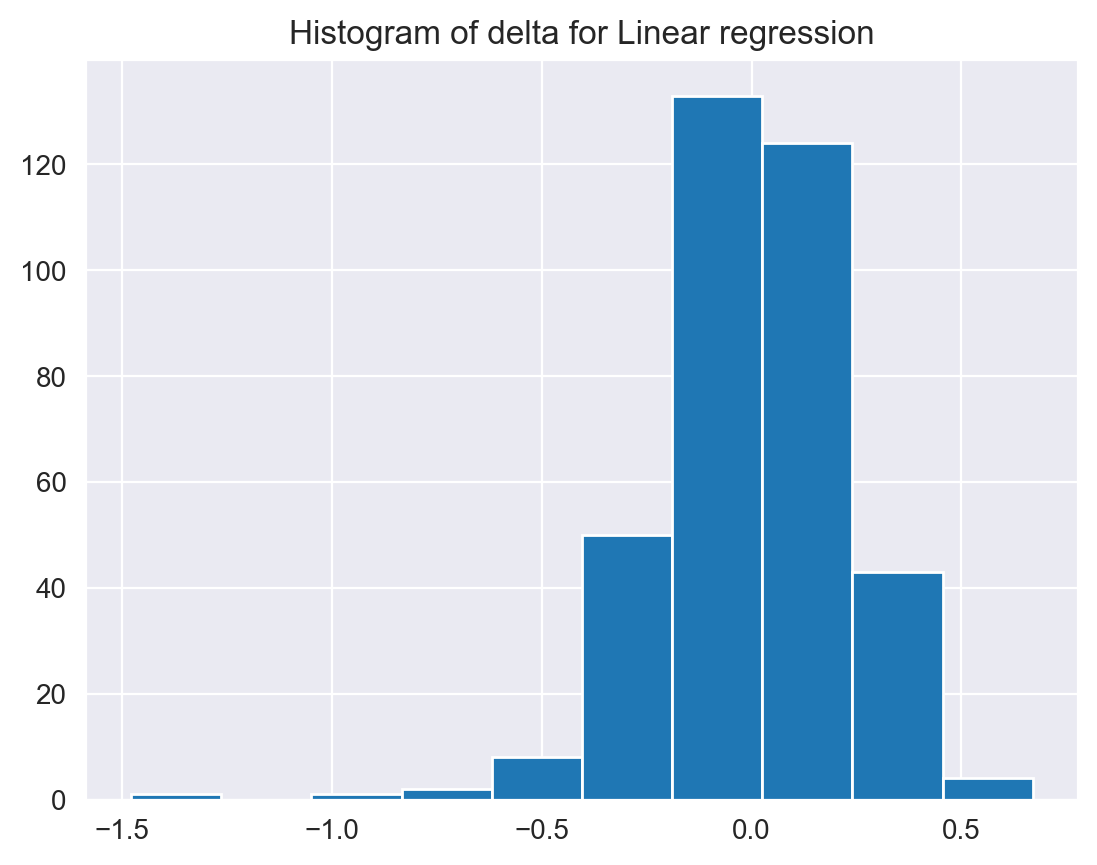

In [394]:
delta_lin = test.values - lin_pred
plt.hist(delta_lin)
plt.title("Histogram of delta for Linear regression")
plt.grid(True)

# Boosting

In [326]:
from catboost import CatBoostRegressor, Pool

train = features[target.index.year < 2020].index
len_train = len(train)

X_train = features.iloc[:len_train,:]
y_train = target.iloc[:len_train]
train_pool = Pool(X_train, y_train)

preds = []
for i in tqdm(range(7, len(test)+7, 7)):

    if i >= len(test):
        i = len(test)

    model = CatBoostRegressor(iterations=1000, depth=5,loss_function='MAE')
    model.fit(train_pool, verbose=False)

    X_train = features.iloc[:len_train+i,:]
    y_train = target.iloc[:len_train+i]
    train_pool = Pool(X_train, y_train)
    prediction = model.predict(train_pool)

    idx = 7 if i % 7 == 0 else i % 7
    preds.extend(prediction[-idx:])

boost_pred = preds

100%|██████████| 53/53 [02:18<00:00,  2.61s/it]


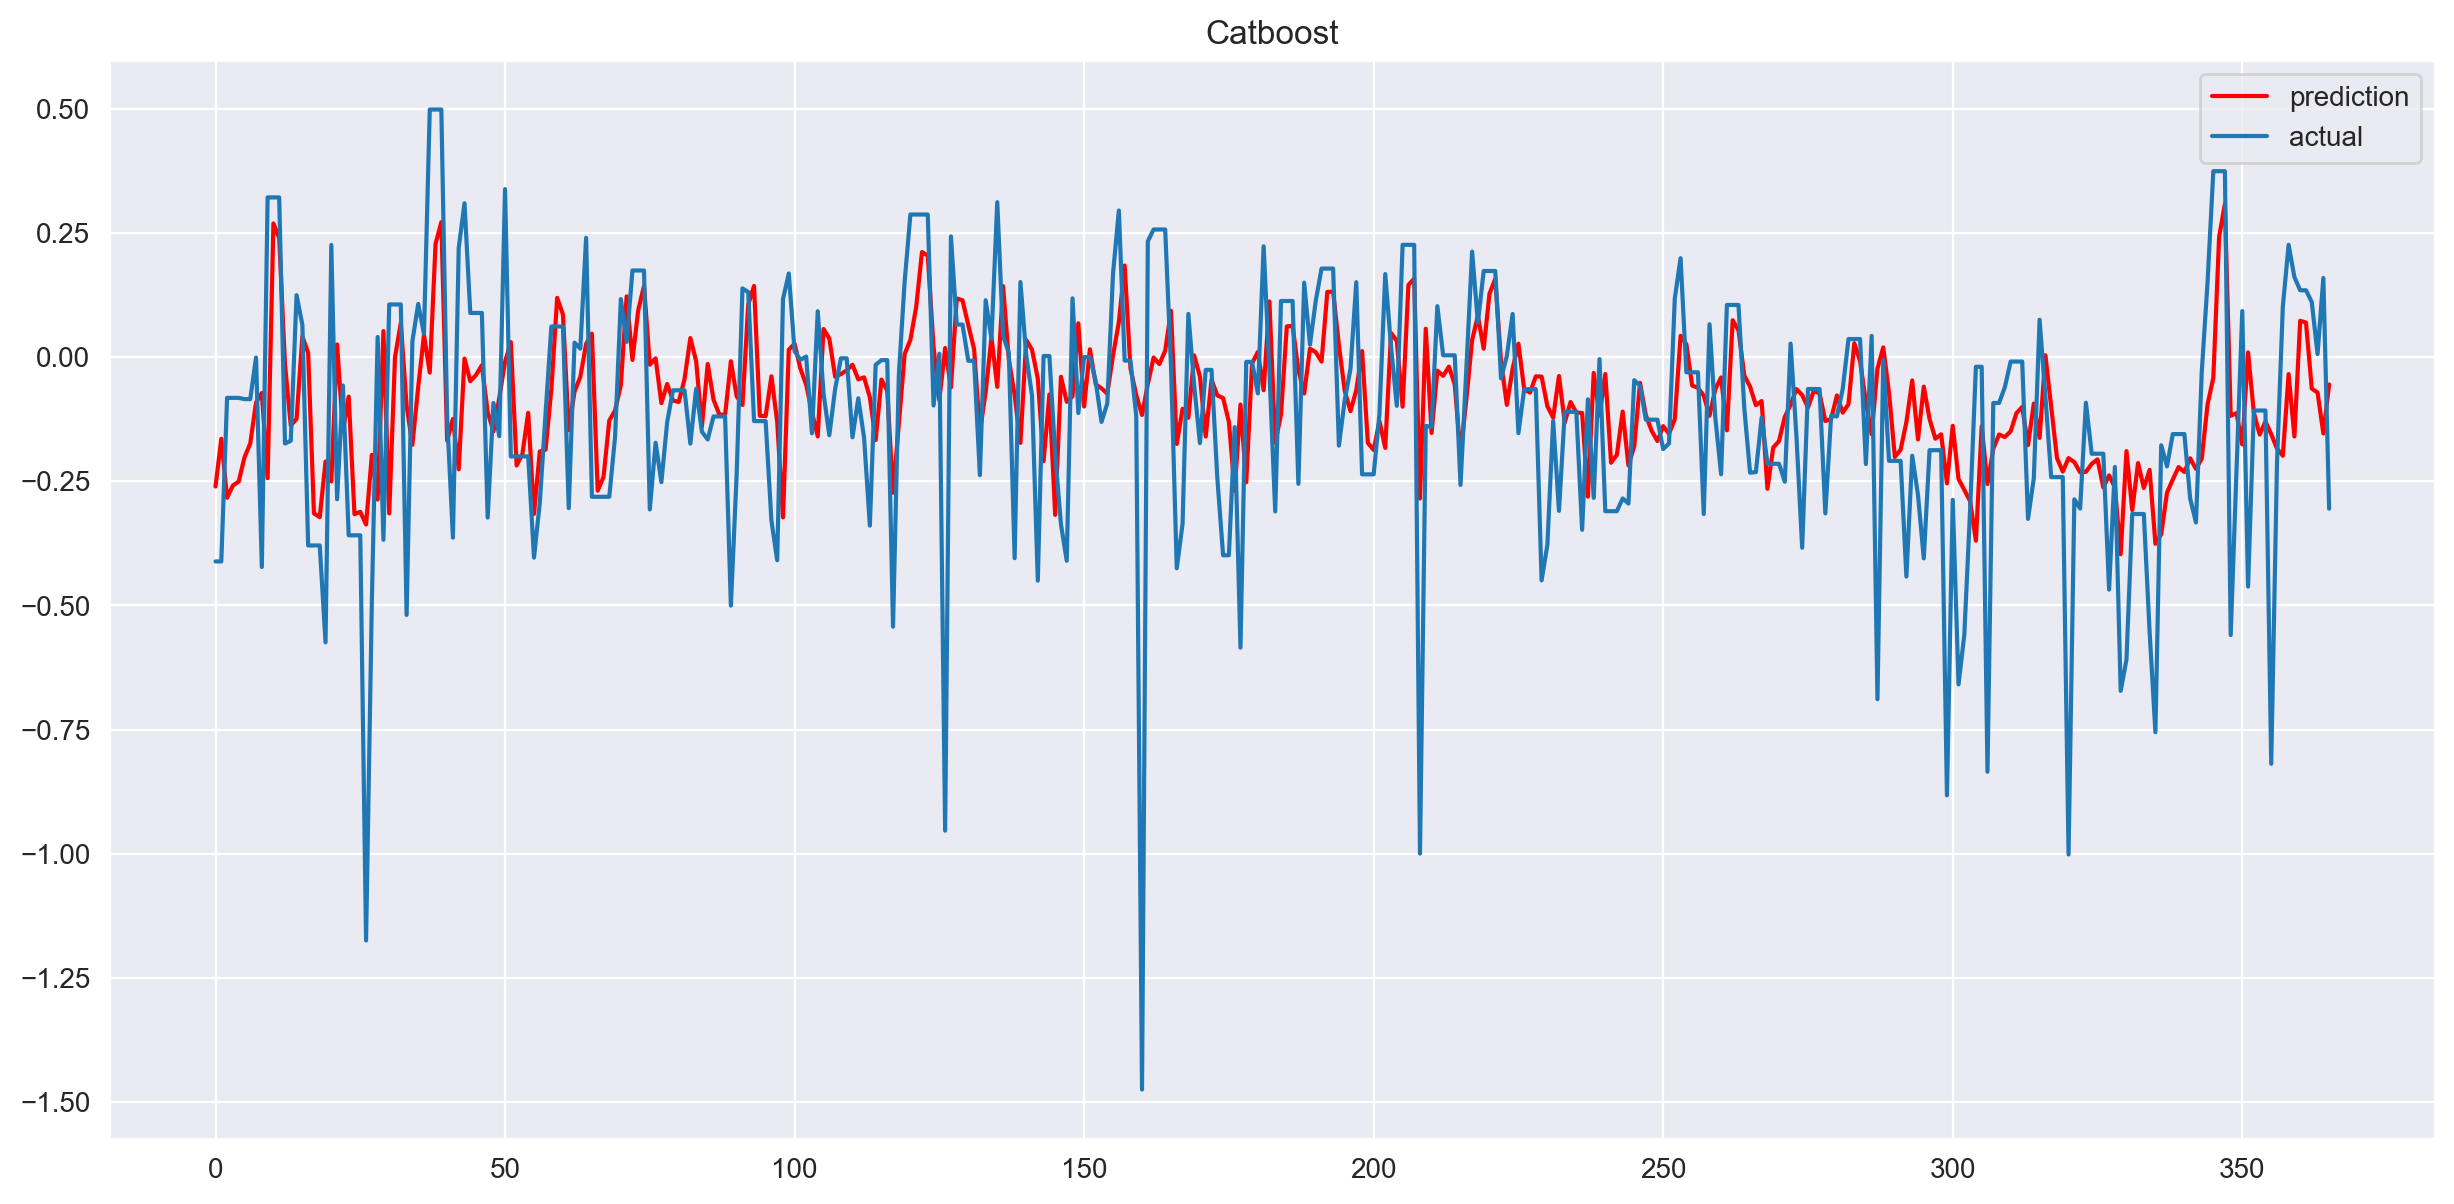

In [396]:
plt.figure(figsize=(15, 7))
plt.plot(boost_pred, "r", label="prediction")
plt.plot(test.values, label="actual")
plt.legend(loc="best")
plt.title("Catboost")
plt.grid(True)

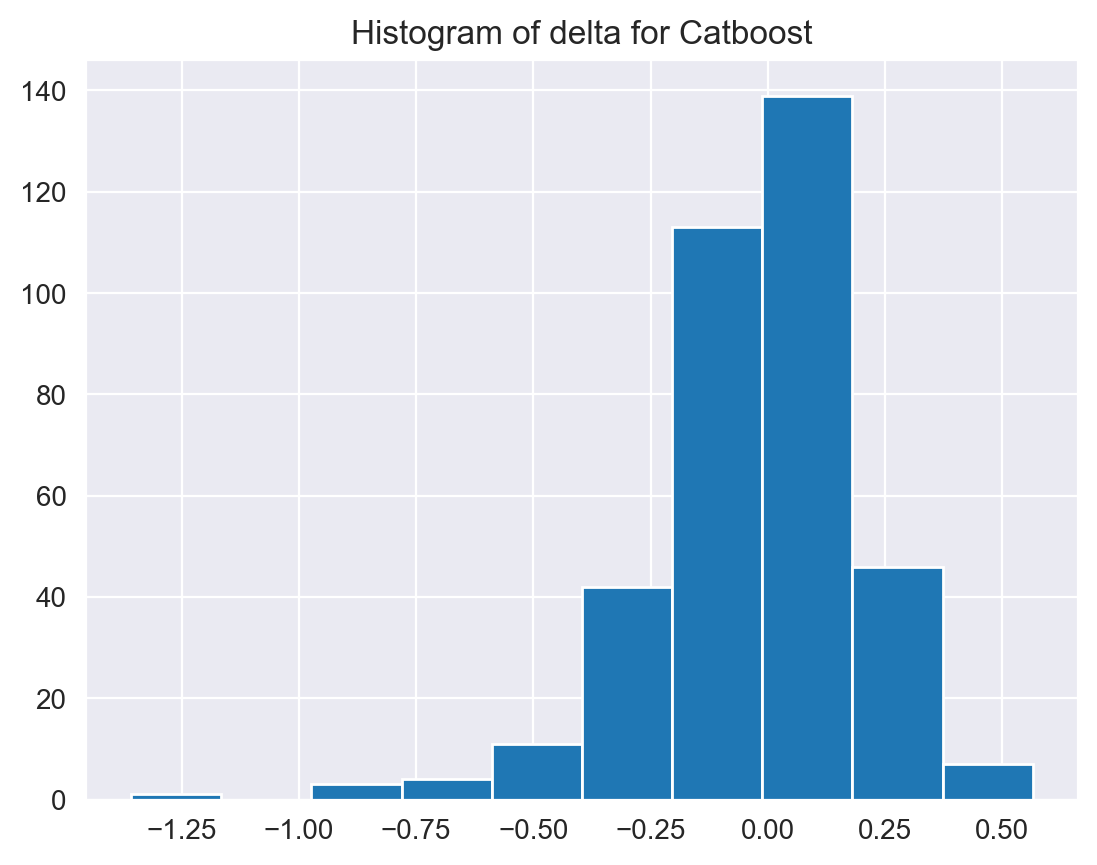

In [395]:
delta_boost = test.values - boost_pred
plt.hist(delta_boost)
plt.title("Histogram of delta for Catboost")
plt.grid(True)

In [329]:
from sklearn.ensemble import GradientBoostingRegressor

train = features[target.index.year < 2020].index
len_train = len(train)

X_train = features.iloc[:len_train,:]
y_train = target.iloc[:len_train]

preds = []
for i in tqdm(range(7, len(test)+7, 7)):

    if i >= len(test):
        i = len(test)

    model =  GradientBoostingRegressor()
    model.fit(X_train, y_train)

    X_train = features.iloc[:len_train+i,:]
    y_train = target.iloc[:len_train+i]
    prediction = model.predict(X_train)

    idx = 7 if i % 7 == 0 else i % 7
    preds.extend(prediction[-idx:])

boost_pred2 = preds

100%|██████████| 53/53 [00:50<00:00,  1.04it/s]


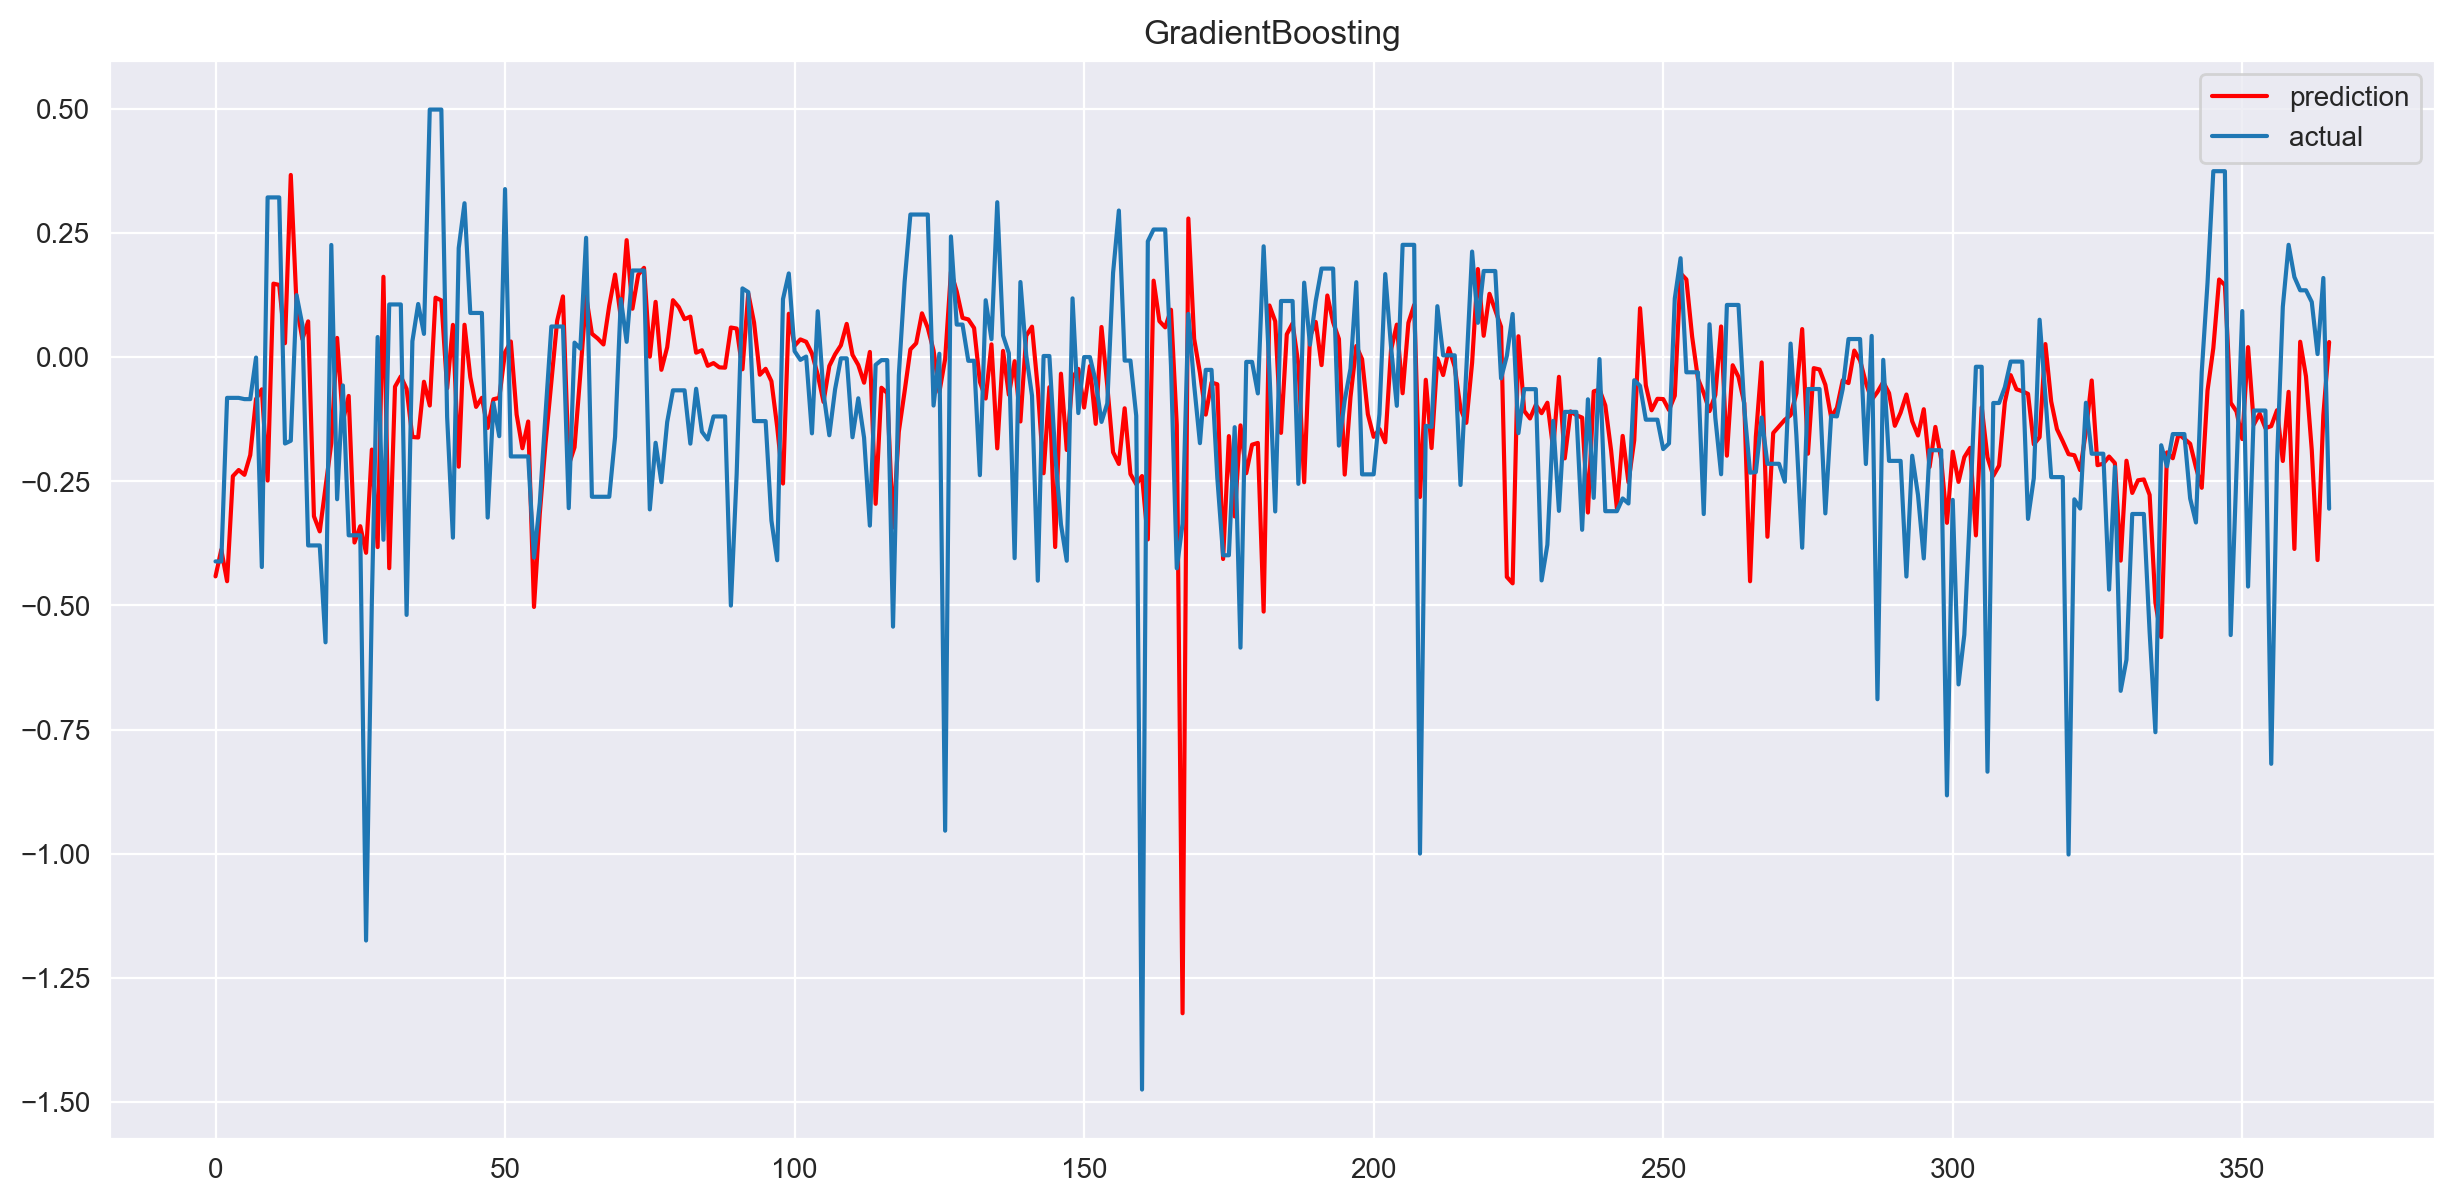

In [397]:
plt.figure(figsize=(15, 7))
plt.plot(boost_pred2, "r", label="prediction")
plt.plot(test.values, label="actual")
plt.legend(loc="best")
plt.title("GradientBoosting")
plt.grid(True)

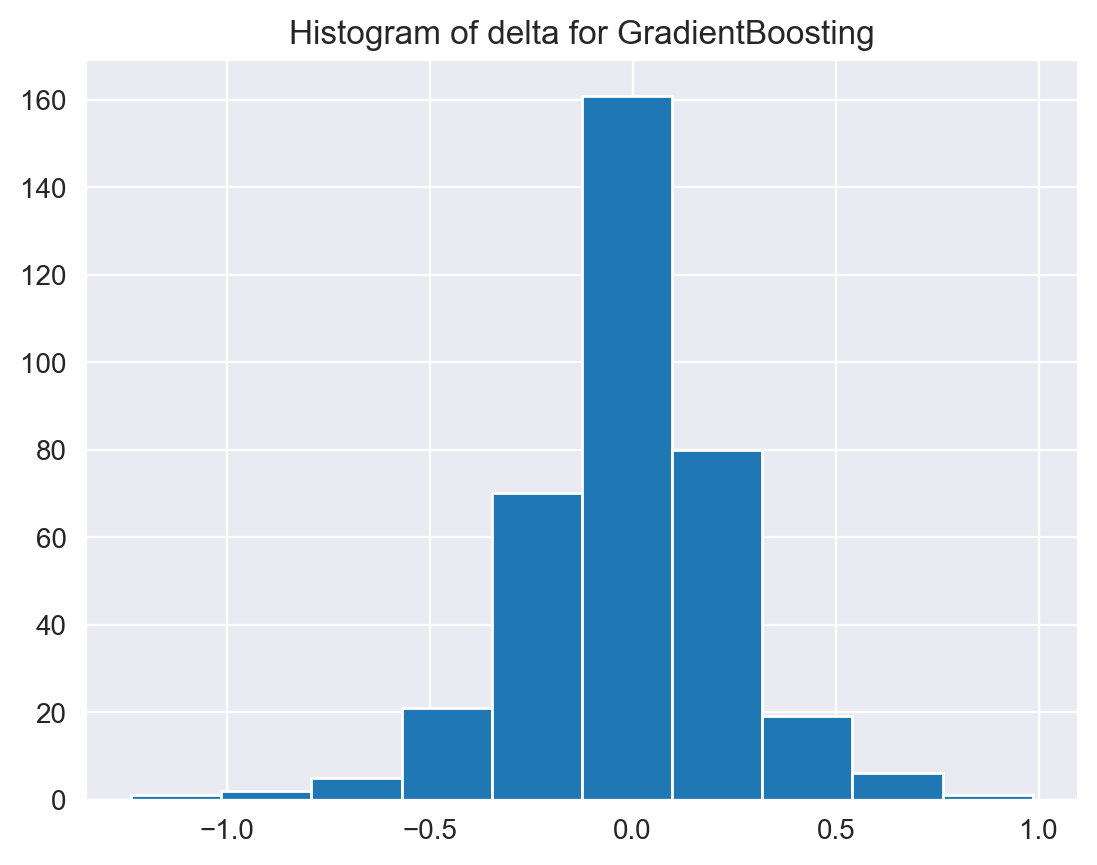

In [398]:
delta_boost2 = test.values - boost_pred2
plt.hist(delta_boost2)
plt.title("Histogram of delta for GradientBoosting")
plt.grid(True)

# SARIMAX

In [338]:
train = features[target.index.year < 2021].index
len_train = len(train)

X_train = features.iloc[:len_train,:].astype(np.float64)
y_train = target.iloc[:len_train].astype(np.float64)
X_train = sm.add_constant(X_train)

preds = []

for i in tqdm(range(7, len(test)+7, 7)):
    model =  pm.auto_arima(y_train, X_train,
                                start_p=1, start_q=1,
                                test='adf',
                                max_p=7, max_q=7, m=5,
                                start_P=0, seasonal=True,
                                d=None, D=None,
                                trace=False,
                                error_action='ignore',
                                suppress_warnings=True,
                                stepwise=True)
    if i >= len(test):
        i = len(test)

    X_train = features.iloc[:len_train+i,:].astype(np.float64)
    y_train = target.iloc[:len_train+i].astype(np.float64)

    n_periods = X_train.shape[0]
    prediction = model.predict(n_periods=n_periods, X=X_train)

    idx = 7 if i % 7 == 0 else i % 7
    preds.extend(prediction[-idx:])

sarimax_pred = preds

  0%|          | 0/53 [00:00<?, ?it/s]

100%|██████████| 53/53 [13:06<00:00, 14.84s/it]


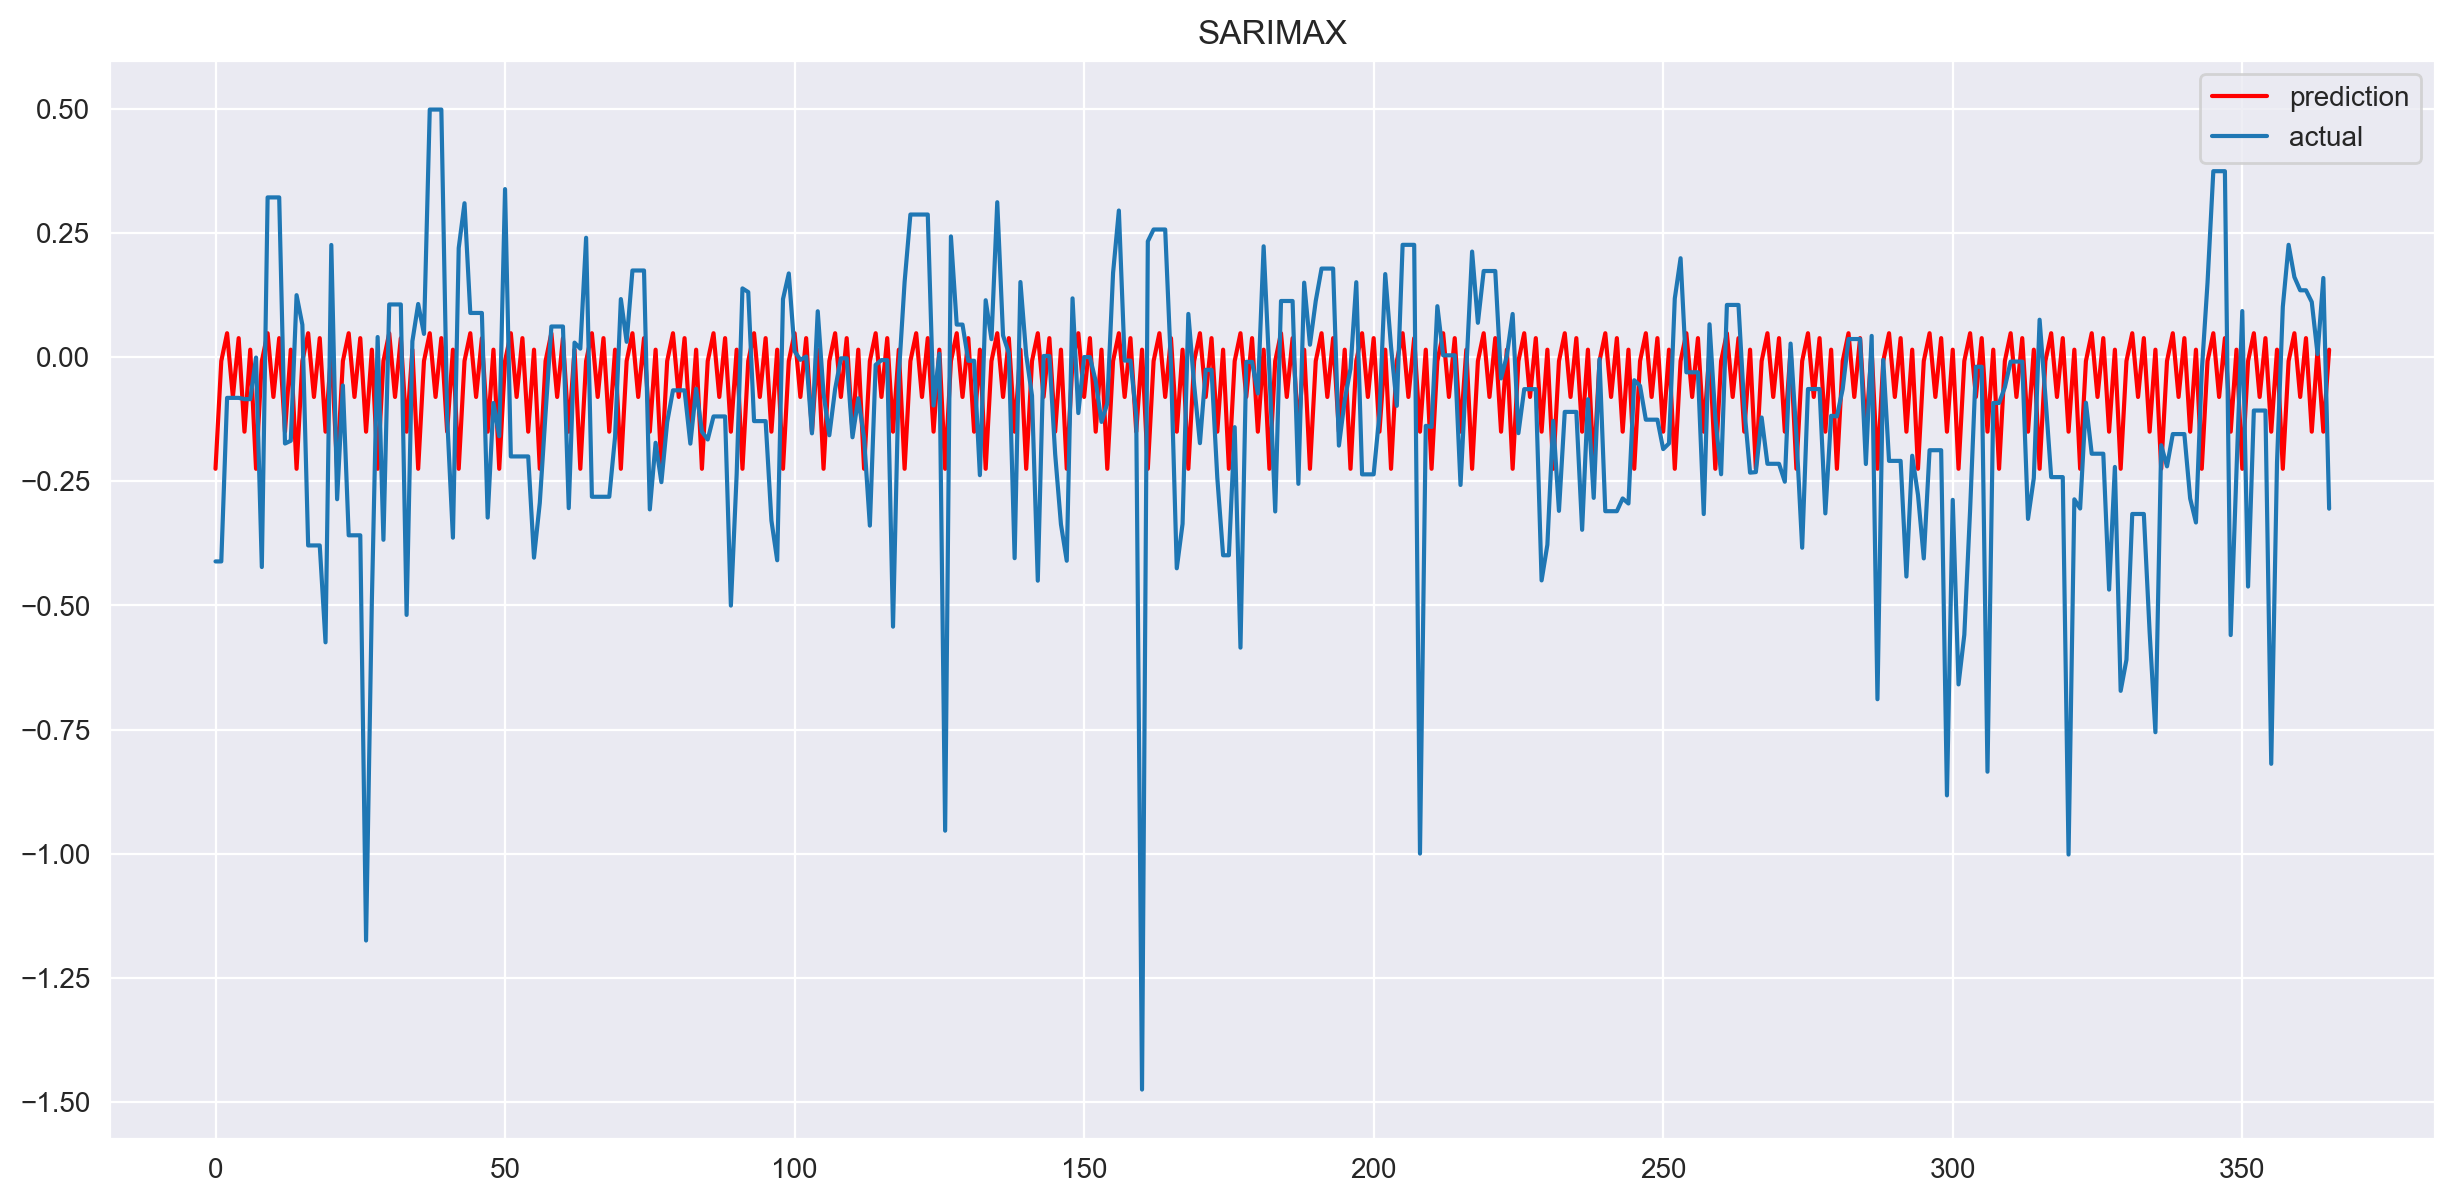

In [339]:
plt.figure(figsize=(15, 7))
plt.plot(sarimax_pred, "r", label="prediction")
plt.plot(test.values, label="actual")
plt.legend(loc="best")
plt.title("SARIMAX")
plt.grid(True)

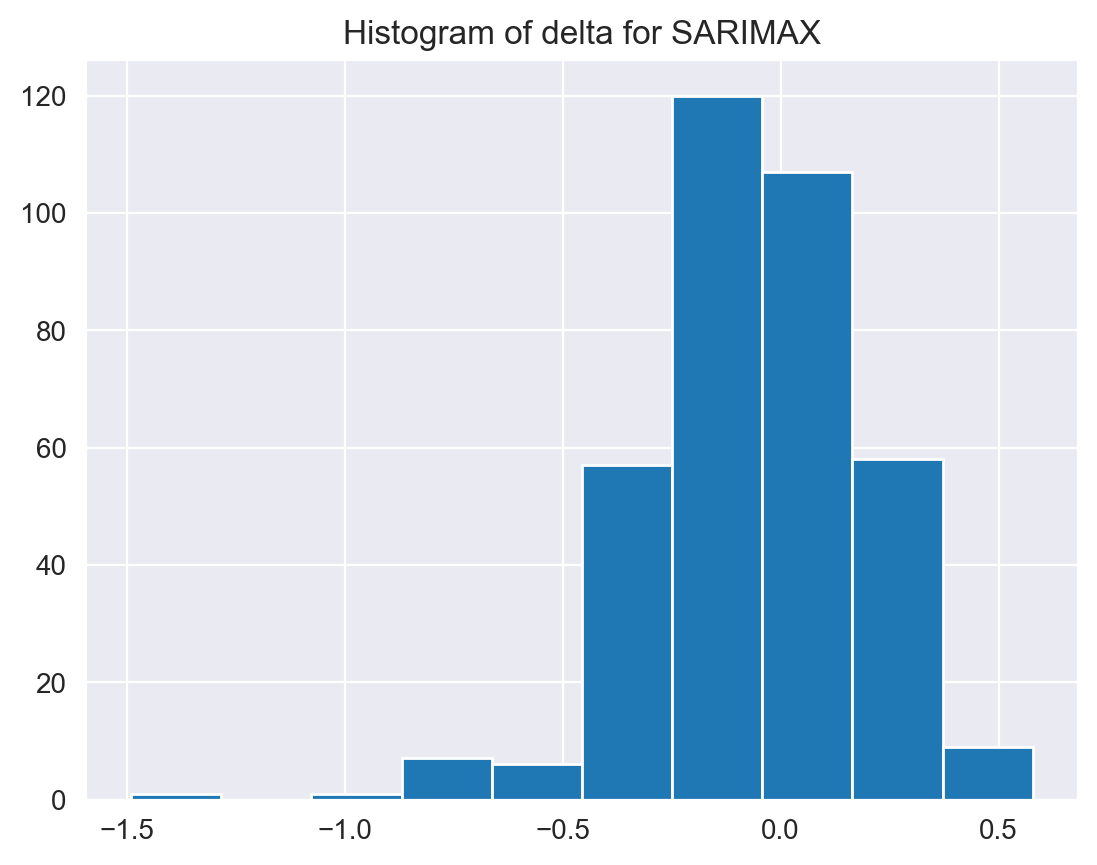

In [340]:
delta_sarimax = test.values - sarimax_pred
plt.hist(delta_sarimax)
plt.title("Histogram of delta for SARIMAX")
plt.grid(True)

# LSTM

In [357]:
lookback = 100
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

main_series = target.values
data_exog_features = features.astype(np.float64)

scaler_main = MinMaxScaler(feature_range=(0, 1))

def create_sequences(data_main, data_exog, lookback):
    X_main, X_exog, y = [], [], []
    for i in range(len(data_main) - lookback):
        X_main.append(data_main[i:i+lookback])
        X_exog.append(data_exog.iloc[i+lookback])
        y.append(data_main[i+lookback])

    X_main = np.array(X_main)[..., np.newaxis]  
    X_exog = np.array(X_exog)
    y = np.array(y)
    return X_main, X_exog, y

train_size = int(len(main_series) - (lookback+len(test)))
X_main_train, X_exog_train, y_train = create_sequences(scaler_main.fit_transform(main_series[:train_size].reshape(-1, 1)).flatten(), data_exog_features.iloc[:train_size], lookback)
X_main_test, X_exog_test, y_test = create_sequences(scaler_main.transform(main_series[train_size:].reshape(-1, 1)).flatten(), data_exog_features.iloc[train_size:], lookback)


X_main_train = torch.FloatTensor(X_main_train)  
X_exog_train = torch.FloatTensor(X_exog_train)  
y_train = torch.FloatTensor(y_train).view(-1, 1)

X_main_test = torch.FloatTensor(X_main_test)  
X_exog_test = torch.FloatTensor(X_exog_test)  
y_test = torch.FloatTensor(y_test).view(-1, 1)

# DataLoader
dataset = torch.utils.data.TensorDataset(X_main_train, X_exog_train, y_train)
train_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)

# DataLoader
dataset = torch.utils.data.TensorDataset(X_main_test, X_exog_test, y_test)
test_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)

# Модель (без изменений)
class HybridLSTM(nn.Module):
    def __init__(self, main_input_size, exog_input_size, hidden_size, output_size, dropout_prob=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=main_input_size,
            hidden_size=hidden_size,
            batch_first=True,
            dropout=dropout_prob
        )
        self.fc_exog = nn.Linear(exog_input_size, hidden_size)
        self.fc_out = nn.Linear(hidden_size * 2, output_size)
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x_main, x_exog):
        lstm_out, _ = self.lstm(x_main)  
        lstm_last = lstm_out[:, -1, :]   
        lstm_last = self.dropout(lstm_last)

        exog_out = self.fc_exog(x_exog)  
        exog_out = self.dropout(exog_out)
        combined = torch.cat([lstm_last, exog_out], dim=1)
        output = self.fc_out(combined)
        return output


model = HybridLSTM(
    main_input_size=1,  
    exog_input_size=data_exog_features.shape[1],
    hidden_size=100,
    output_size=1
)


optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

for epoch in range(100):
    for x_main, x_exog, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(x_main, x_exog)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
    print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

Epoch 1, Loss: 2.8162
Epoch 2, Loss: 2.1248
Epoch 3, Loss: 1.2441
Epoch 4, Loss: 0.4801
Epoch 5, Loss: 0.6708
Epoch 6, Loss: 0.3034
Epoch 7, Loss: 0.4123
Epoch 8, Loss: 0.1025
Epoch 9, Loss: 0.1322
Epoch 10, Loss: 0.1439
Epoch 11, Loss: 0.0360
Epoch 12, Loss: 0.0447
Epoch 13, Loss: 0.0189
Epoch 14, Loss: 0.0274
Epoch 15, Loss: 0.0540
Epoch 16, Loss: 0.0219
Epoch 17, Loss: 0.0229
Epoch 18, Loss: 0.0320
Epoch 19, Loss: 0.0156
Epoch 20, Loss: 0.0098
Epoch 21, Loss: 0.0100
Epoch 22, Loss: 0.0158
Epoch 23, Loss: 0.0118
Epoch 24, Loss: 0.0257
Epoch 25, Loss: 0.0115
Epoch 26, Loss: 0.0388
Epoch 27, Loss: 0.0134
Epoch 28, Loss: 0.0101
Epoch 29, Loss: 0.0120
Epoch 30, Loss: 0.0439
Epoch 31, Loss: 0.0198
Epoch 32, Loss: 0.0228
Epoch 33, Loss: 0.0262
Epoch 34, Loss: 0.0139
Epoch 35, Loss: 0.0255
Epoch 36, Loss: 0.0220
Epoch 37, Loss: 0.0139
Epoch 38, Loss: 0.0094
Epoch 39, Loss: 0.0187
Epoch 40, Loss: 0.0094
Epoch 41, Loss: 0.0086
Epoch 42, Loss: 0.0117
Epoch 43, Loss: 0.0105
Epoch 44, Loss: 0.00

In [358]:
with torch.no_grad():
    train_predictions = model(X_main_train, X_exog_train).numpy().flatten()


train_predictions = scaler_main.inverse_transform(train_predictions.reshape(-1, 1)).flatten()
y_train_orig = scaler_main.inverse_transform(y_train.numpy().reshape(-1, 1)).flatten()

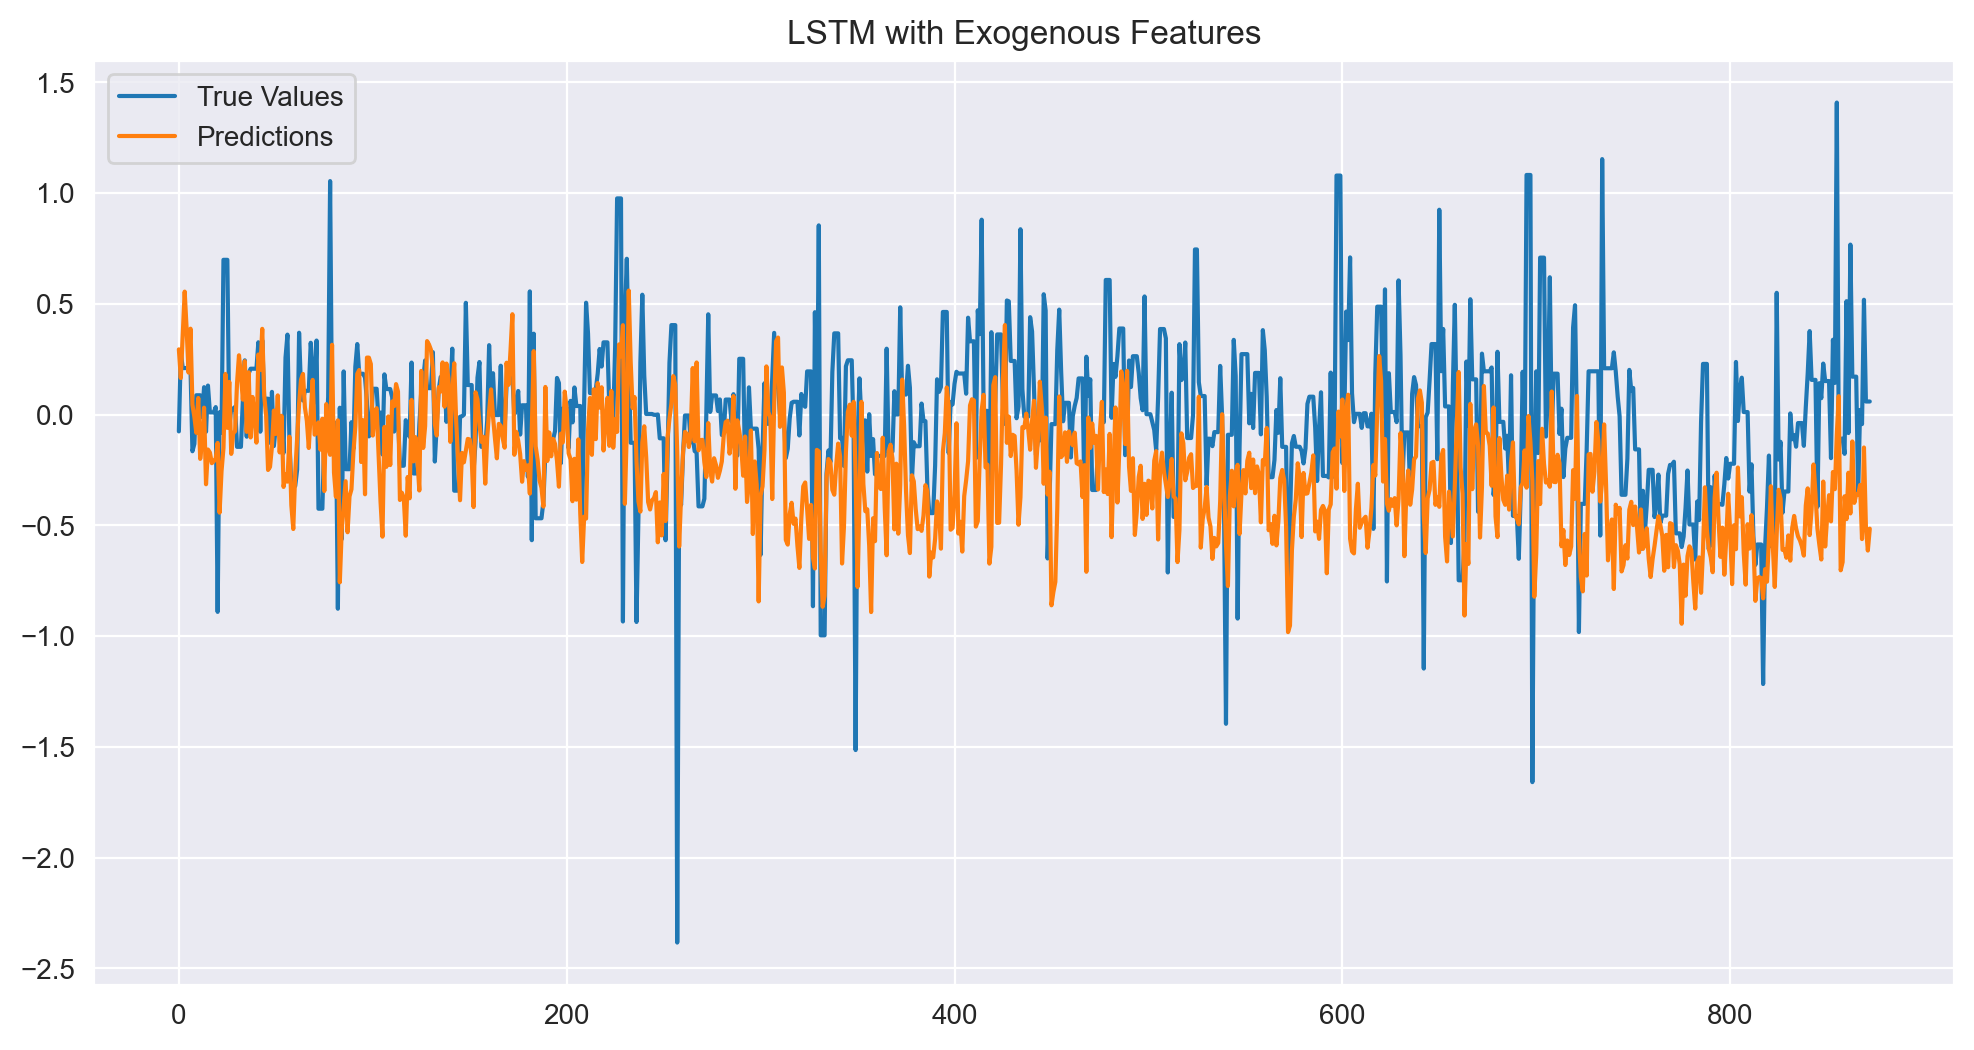

In [359]:
plt.figure(figsize=(12, 6))
plt.plot(y_train_orig, label='True Values')
plt.plot(train_predictions, label='Predictions')
plt.title('LSTM with Exogenous Features')
plt.legend()
plt.grid(True)
plt.show()

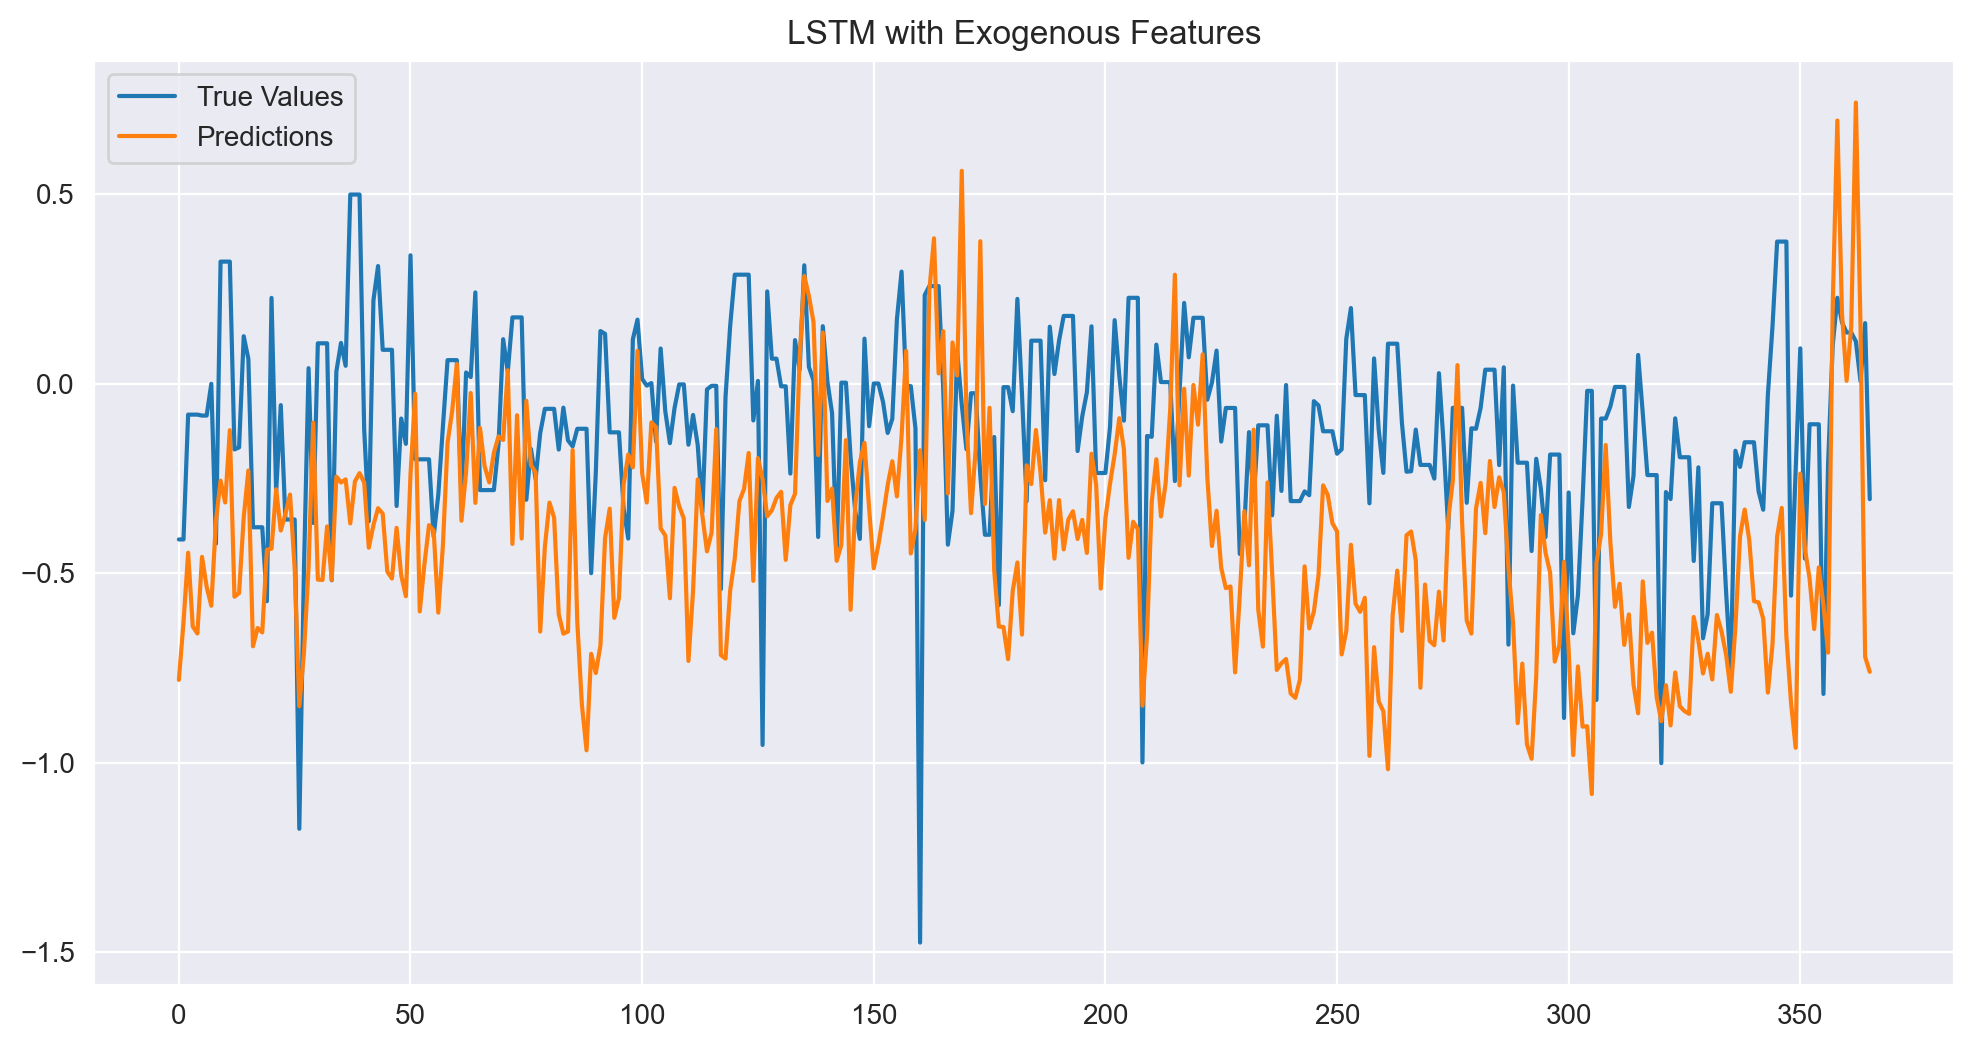

In [360]:
with torch.no_grad():
    test_predictions = model(X_main_test, X_exog_test).numpy().flatten()

lstm_pred = scaler_main.inverse_transform(test_predictions.reshape(-1, 1)).flatten()
y_test_orig = scaler_main.inverse_transform(y_test.numpy().reshape(-1, 1)).flatten()

plt.figure(figsize=(12, 6))
plt.plot(y_test_orig, label='True Values')
plt.plot(lstm_pred, label='Predictions')
plt.title('LSTM with Exogenous Features')
plt.legend()
plt.grid(True)
plt.show()


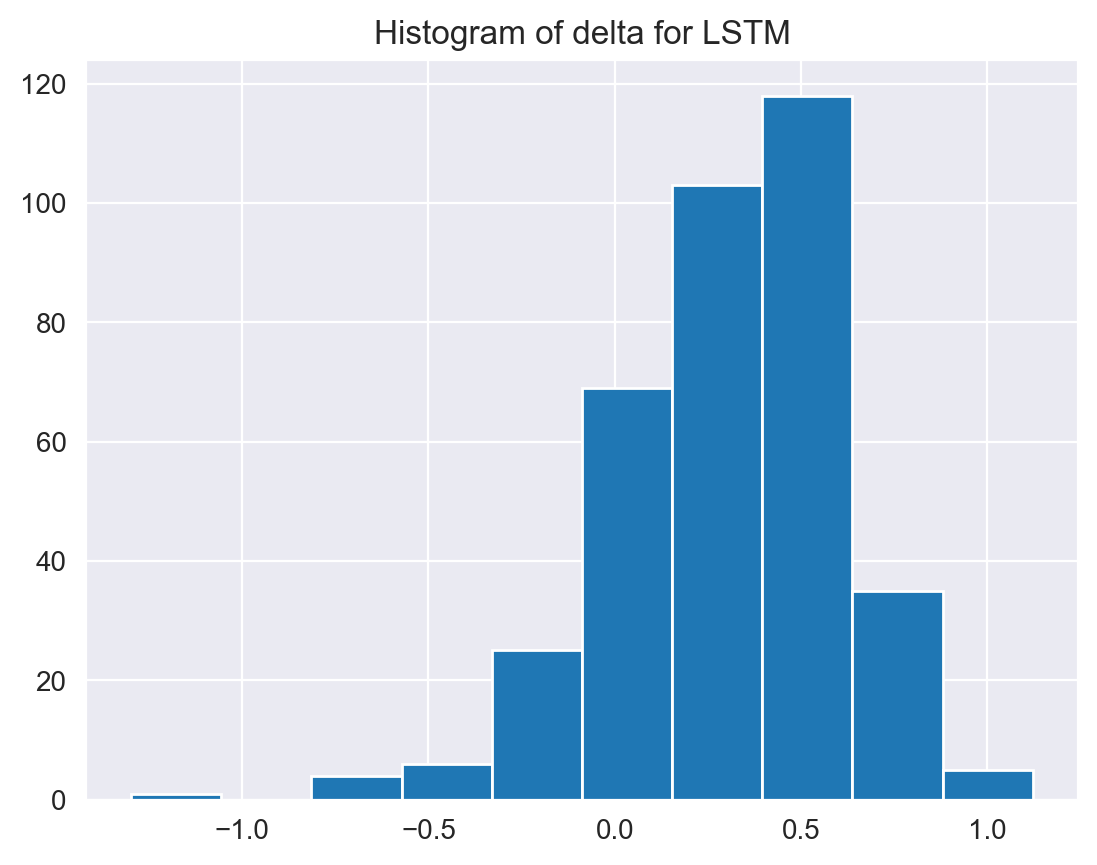

In [361]:
delta = y_test_orig - lstm_pred
plt.title('Histogram of delta for LSTM')
plt.hist(delta)
plt.show()

# LSTM + attention

Добавим слой attention, чтобы лучше учесть пики.

In [385]:
import torch.nn.functional as F

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
lookback = 100

main_series = target.values
data_exog_features = features.astype(np.float64)

scaler_main = MinMaxScaler(feature_range=(0, 1))

def create_sequences(data_main, data_exog, lookback):
    X_main, X_exog, y = [], [], []
    for i in range(len(data_main) - lookback):
        X_main.append(data_main[i:i+lookback])
        X_exog.append(data_exog.iloc[i+lookback])
        y.append(data_main[i+lookback])

    X_main = np.array(X_main)[..., np.newaxis]  
    X_exog = np.array(X_exog)
    y = np.array(y)
    return X_main, X_exog, y

train_size = int(len(main_series) - (lookback+len(test)))

X_main_train, X_exog_train, y_train = create_sequences(scaler_main.fit_transform(main_series[:train_size].reshape(-1, 1)).flatten(), data_exog_features.iloc[:train_size], lookback)
X_main_test, X_exog_test, y_test = create_sequences(scaler_main.transform(main_series[train_size:].reshape(-1, 1)).flatten(), data_exog_features.iloc[train_size:], lookback)

X_main_train = torch.FloatTensor(X_main_train) 
X_exog_train = torch.FloatTensor(X_exog_train)  
y_train = torch.FloatTensor(y_train).view(-1, 1)

X_main_test = torch.FloatTensor(X_main_test)  
X_exog_test = torch.FloatTensor(X_exog_test)  
y_test = torch.FloatTensor(y_test).view(-1, 1)


dataset_train = torch.utils.data.TensorDataset(
    X_main_train, X_exog_train, y_train
)
train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=64, shuffle=False)

dataset_test = torch.utils.data.TensorDataset(
    X_main_test, X_exog_test, y_test
)
test_loader = torch.utils.data.DataLoader(dataset_test, batch_size=64, shuffle=False)


class HybridLSTMWithAttention(nn.Module):
    def __init__(self, main_input_size, exog_input_size, hidden_size, output_size, dropout_prob=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=main_input_size,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=False,
            dropout=dropout_prob  
        )
        
        
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_size, 1, bias=False)
        )

        self.dropout = nn.Dropout(dropout_prob)
        self.fc_exog = nn.Linear(exog_input_size, hidden_size)
        self.fc_out = nn.Linear(hidden_size * 2, output_size)

    def forward(self, x_main, x_exog):
        # LSTM layer
        lstm_out, (h_n, c_n) = self.lstm(x_main)
        
        # Attention mechanism
        attn_weights = F.softmax(self.attention(lstm_out).squeeze(2), dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), lstm_out).squeeze(1)
        context = self.dropout(context)  

        
        exog_out = self.fc_exog(x_exog)
        exog_out = self.dropout(exog_out)  

        
        combined = torch.cat([context, exog_out], dim=1)
        output = self.fc_out(self.dropout(combined))  
        
        return output


model = HybridLSTMWithAttention(
    main_input_size=1,
    exog_input_size=data_exog_features.shape[1],
    hidden_size=100,
    output_size=1
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.MSELoss()

for epoch in range(200):
    for x_main, x_exog, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(x_main, x_exog)

        loss = criterion(outputs,y_batch)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

    print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

Epoch 1, Loss: 10.4634
Epoch 2, Loss: 7.8021
Epoch 3, Loss: 15.6856
Epoch 4, Loss: 17.1438
Epoch 5, Loss: 13.6353
Epoch 6, Loss: 9.3556
Epoch 7, Loss: 11.0173
Epoch 8, Loss: 7.3523
Epoch 9, Loss: 10.9838
Epoch 10, Loss: 6.6491
Epoch 11, Loss: 8.3362
Epoch 12, Loss: 5.2773
Epoch 13, Loss: 7.8813
Epoch 14, Loss: 6.1768
Epoch 15, Loss: 5.4319
Epoch 16, Loss: 3.8989
Epoch 17, Loss: 3.1163
Epoch 18, Loss: 4.4408
Epoch 19, Loss: 2.9812
Epoch 20, Loss: 3.6011
Epoch 21, Loss: 3.5855
Epoch 22, Loss: 3.5369
Epoch 23, Loss: 2.9494
Epoch 24, Loss: 2.1714
Epoch 25, Loss: 1.8743
Epoch 26, Loss: 1.8964
Epoch 27, Loss: 1.7575
Epoch 28, Loss: 1.1612
Epoch 29, Loss: 1.4823
Epoch 30, Loss: 1.2394
Epoch 31, Loss: 0.9089
Epoch 32, Loss: 0.8036
Epoch 33, Loss: 0.8859
Epoch 34, Loss: 0.8344
Epoch 35, Loss: 0.4810
Epoch 36, Loss: 0.4335
Epoch 37, Loss: 0.6691
Epoch 38, Loss: 0.5182
Epoch 39, Loss: 0.3335
Epoch 40, Loss: 0.4301
Epoch 41, Loss: 0.3482
Epoch 42, Loss: 0.2566
Epoch 43, Loss: 0.2532
Epoch 44, Loss

In [386]:
with torch.no_grad():
    train_predictions = model(X_main_train, X_exog_train).numpy().flatten()


train_predictions = scaler_main.inverse_transform(train_predictions.reshape(-1, 1)).flatten()
y_train_orig = scaler_main.inverse_transform(y_train.numpy().reshape(-1, 1)).flatten()

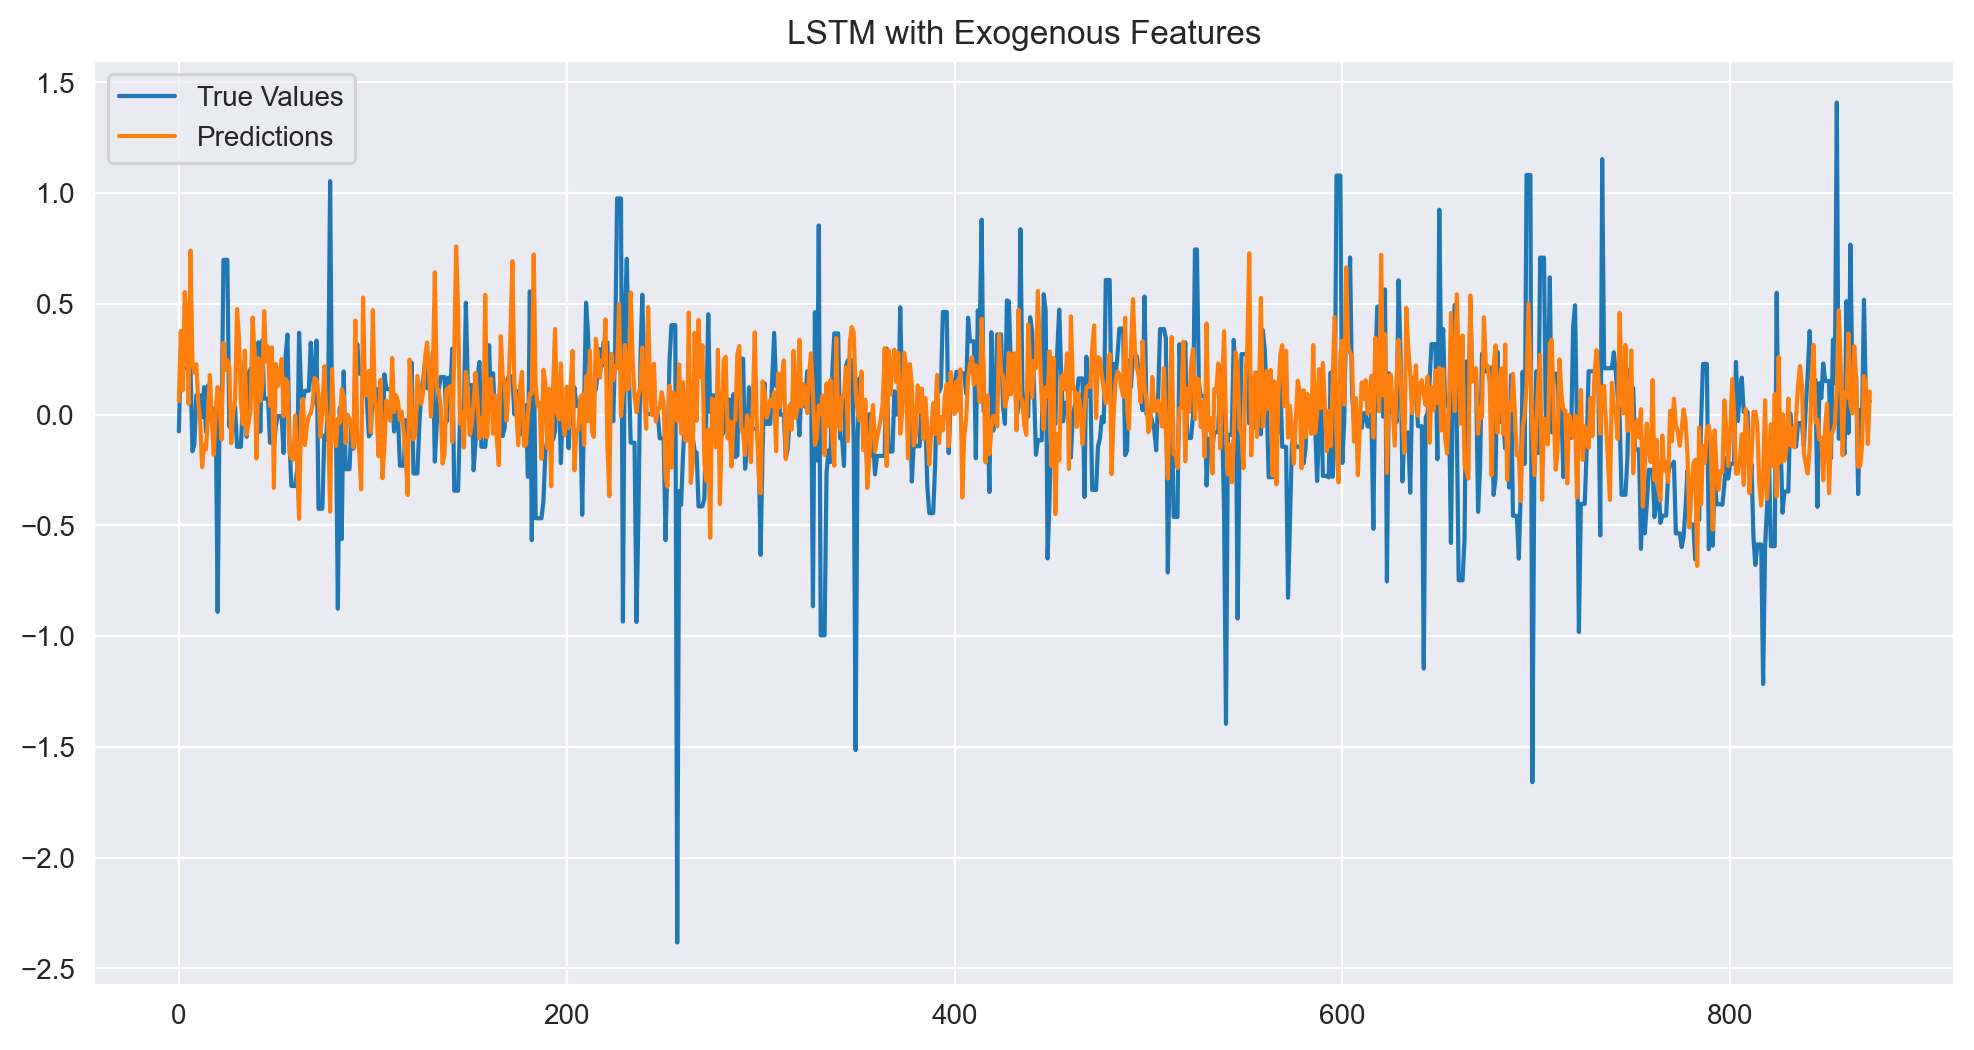

In [387]:

plt.figure(figsize=(12, 6))
plt.plot(y_train_orig, label='True Values')
plt.plot(train_predictions, label='Predictions')
plt.title('LSTM with Exogenous Features')
plt.legend()
plt.show()

In [388]:
with torch.no_grad():
    test_predictions = model(X_main_test, X_exog_test).numpy().flatten()

lstm_att_pred = scaler_main.inverse_transform(test_predictions.reshape(-1, 1)).flatten()
y_test_orig = scaler_main.inverse_transform(y_test.numpy().reshape(-1, 1)).flatten()

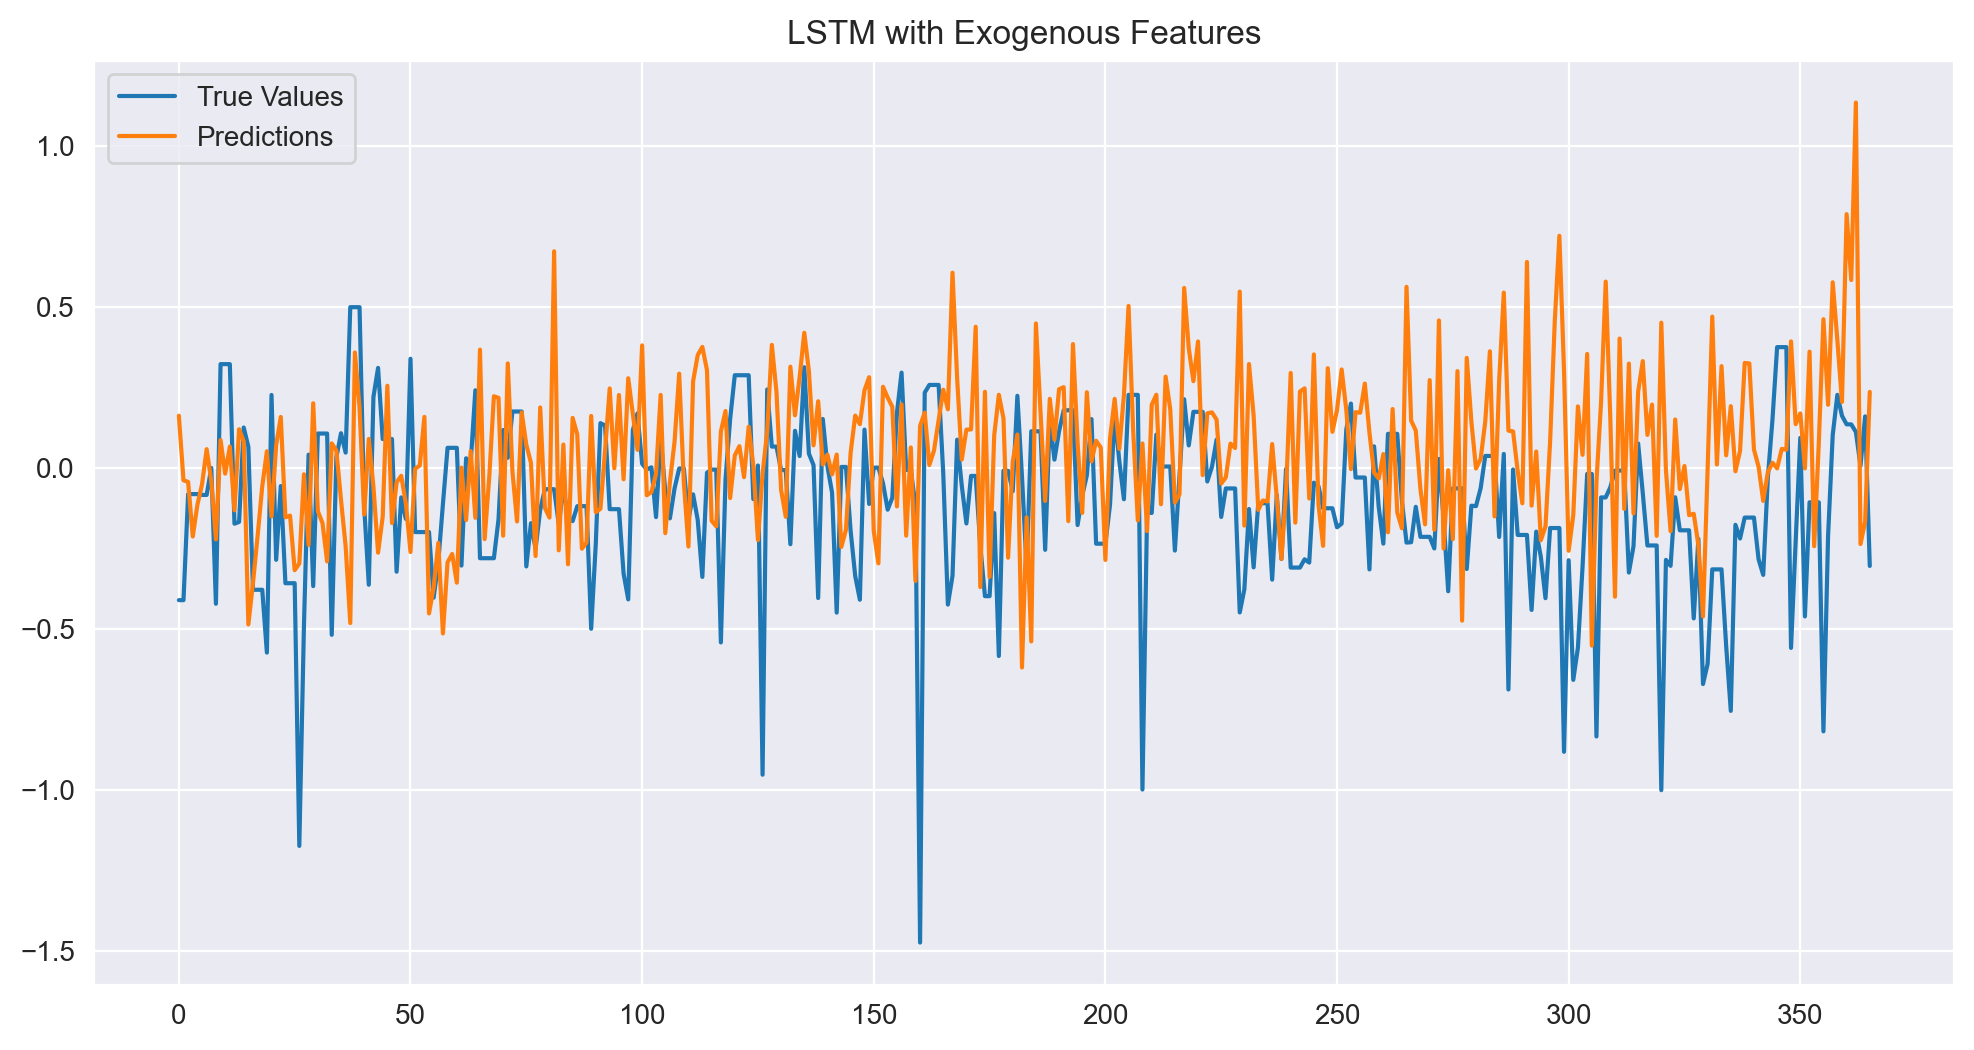

In [389]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_orig, label='True Values')
plt.plot(lstm_att_pred, label='Predictions')
plt.title('LSTM with Exogenous Features')
plt.legend()
plt.show()

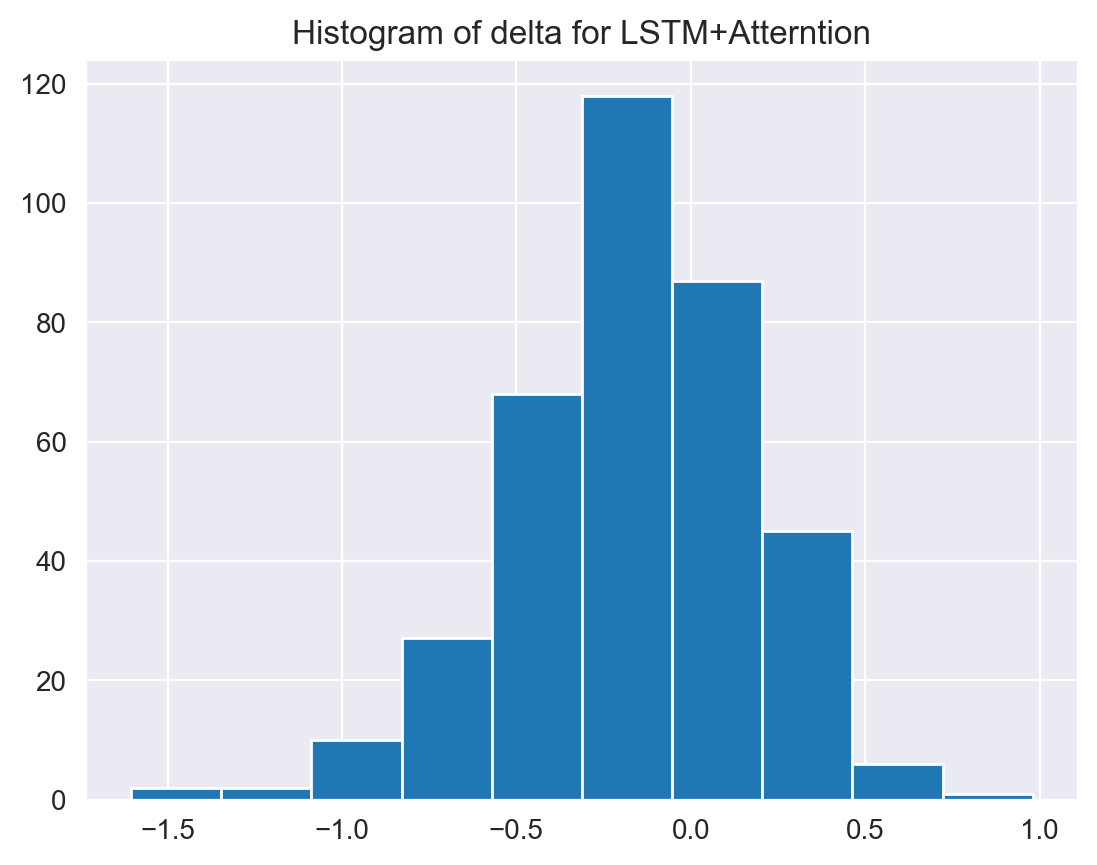

In [390]:
delta = y_test_orig - lstm_att_pred
plt.title('Histogram of delta for LSTM+Atterntion')
plt.hist(delta)
plt.show()

# Results

Сравним результаты всех моделей:

In [368]:
from metric import FinEffect
eff = FinEffect()

In [369]:
def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    value = round(eff.model_effct(y_pred, y_true) * 100, 10)
    strike_share = np.sum(np.abs(y_true - y_pred) > 0.42) / len(y_true)
    return mae, value, strike_share

In [391]:
df = pd.DataFrame(columns=['MAE', "FinEff", "Strikes_share"])

In [392]:
df.loc['Lin_reg_advanced'] = calc_metrics(test, lin_pred)
df.loc['Boosting_advanced_catboost'] = calc_metrics(test, boost_pred) 
df.loc['Boosting_advanced_gradient'] = calc_metrics(test, boost_pred2) 
df.loc['SARIMAX'] = calc_metrics(test, sarimax_pred) 
df.loc['LSTM'] = calc_metrics(test, lstm_pred) 
df.loc['LSTM+Attention'] = calc_metrics(test, lstm_att_pred) 



In [393]:
df

,MAE,FinEff,Strikes_share
Lin_reg_advanced,0.165307,-0.011227,0.049180
Boosting_advanced_catboost,0.157918,0.005081,0.060109
Boosting_advanced_gradient,0.184092,-0.022141,0.087432
SARIMAX,0.199062,-0.019092,0.076503
LSTM,0.369605,-0.346396,0.423497
LSTM+Attention,0.294671,-0.064298,0.215847


Видим, что лучший результат по MAE и финансовому эффекту показывает Catboost. Посмотрим на его остатки:

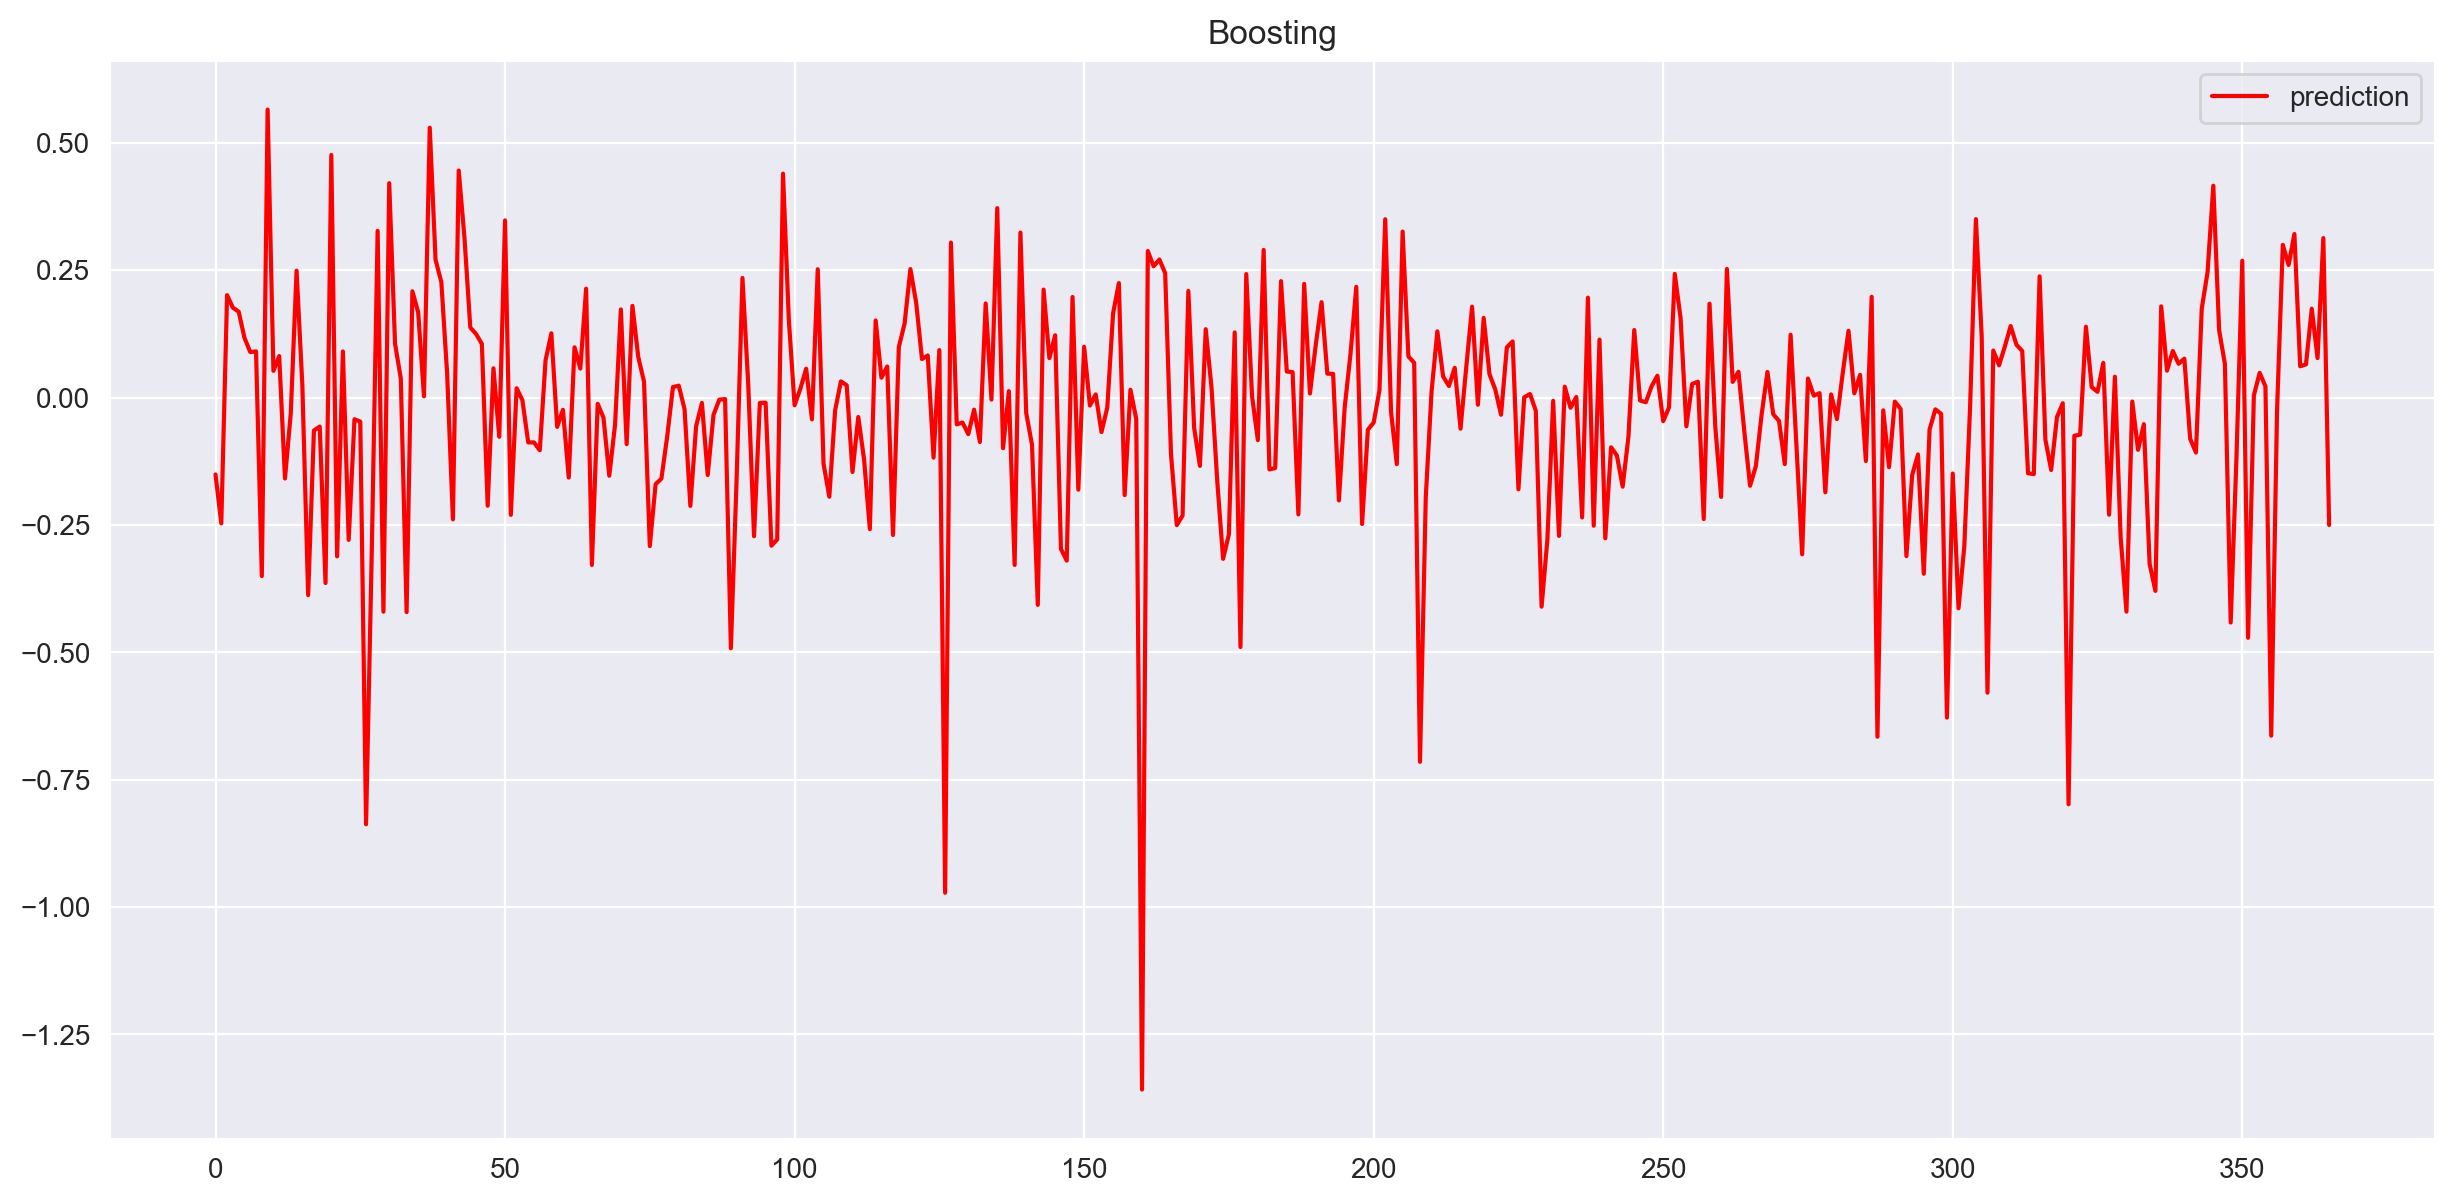

In [373]:
plt.figure(figsize=(15, 7))
plt.plot(delta_boost, "r", label="prediction")
plt.legend(loc="best")
plt.title("Boosting")
plt.grid(True)

In [374]:
import statsmodels.tsa.stattools as ts
results = ts.adfuller(delta_boost)
print(f'p-value ADF:{results[1]}')

p-value ADF:0.0


Остатки стационарны